#PR Review Statistics: AI vs Human
## Comprehensive Analysis for Maintenance Burden Study

This notebook calculates all review metrics comparing AI-generated and Human-generated PRs.

**Prerequisites:**
1. Human review data files uploaded to Google Drive
2. Internet connection to download AI data from HuggingFace

##Step 1: Setup & Mount Google Drive

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted!")
print("\nYour files should be in: /content/drive/MyDrive/")

Mounted at /content/drive
Google Drive mounted!

Your files should be in: /content/drive/MyDrive/


In [2]:
# Install required packages
!pip install -q pyarrow huggingface-hub

import pandas as pd
import numpy as np
from datetime import datetime
import json
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("All packages installed!")
print(f"   Pandas version: {pd.__version__}")
print(f"   NumPy version: {np.__version__}")

All packages installed!
   Pandas version: 2.2.2
   NumPy version: 2.0.2


## Step 2: Configure File Paths

**IMPORTANT:** Update the paths below to match where you uploaded your Human review data files in Google Drive.

In [3]:

HUMAN_REVIEWS_PATH = '/content/drive/MyDrive/human_pr_reviews.parquet'
HUMAN_REVIEW_COMMENTS_PATH = '/content/drive/MyDrive/human_pr_review_comments.parquet'
HUMAN_PR_COMMENTS_PATH = '/content/drive/MyDrive/human_pr_comments.parquet'
HUMAN_PR_COMMITS_PATH = '/content/drive/MyDrive/human_pr_commits.parquet'
HUMAN_PR_COMMIT_DETAILS_PATH = '/content/drive/MyDrive/human_pr_commit_details.parquet'

print("Configured paths:")
print(f"   Human reviews: {HUMAN_REVIEWS_PATH}")
print(f"   Human review comments: {HUMAN_REVIEW_COMMENTS_PATH}")
print(f"   Human PR comments: {HUMAN_PR_COMMENTS_PATH}")

Configured paths:
   Human reviews: /content/drive/MyDrive/human_pr_reviews.parquet
   Human review comments: /content/drive/MyDrive/human_pr_review_comments.parquet
   Human PR comments: /content/drive/MyDrive/human_pr_comments.parquet


## Step 3: Load Data

Loading both AI data (from HuggingFace) and Human data (from your Drive)

In [4]:
# Load AI data from HuggingFace (AIDev-pop dataset)
print("Loading AI data from HuggingFace...\n")

ai_prs = pd.read_parquet("hf://datasets/hao-li/AIDev/pull_request.parquet")
ai_reviews = pd.read_parquet("hf://datasets/hao-li/AIDev/pr_reviews.parquet")
ai_review_comments = pd.read_parquet("hf://datasets/hao-li/AIDev/pr_review_comments_v2.parquet")
ai_commits = pd.read_parquet("hf://datasets/hao-li/AIDev/pr_commits.parquet")
ai_comments = pd.read_parquet("hf://datasets/hao-li/AIDev/pr_comments.parquet")
ai_timeline = pd.read_parquet("hf://datasets/hao-li/AIDev/pr_timeline.parquet")

print(f"AI Data Loaded:")
print(f"   PRs: {len(ai_prs):,}")
print(f"   Reviews: {len(ai_reviews):,}")
print(f"   Review comments: {len(ai_review_comments):,}")
print(f"   Commits: {len(ai_commits):,}")
print(f"   PR comments: {len(ai_comments):,}")

Loading AI data from HuggingFace...

AI Data Loaded:
   PRs: 33,596
   Reviews: 28,875
   Review comments: 26,868
   Commits: 88,576
   PR comments: 39,122


In [5]:
# Load Human data from Google Drive
print("\nLoading Human data from Google Drive...\n")

try:
    human_prs = pd.read_parquet("hf://datasets/hao-li/AIDev/human_pull_request.parquet")
    print(f"Human PRs: {len(human_prs):,}")
except Exception as e:
    print(f"Error loading Human PRs: {e}")

try:
    human_reviews = pd.read_parquet(HUMAN_REVIEWS_PATH)
    print(f"Human reviews: {len(human_reviews):,}")
except Exception as e:
    print(f"Error loading Human reviews: {e}")
    print(f"   Check path: {HUMAN_REVIEWS_PATH}")

try:
    human_review_comments = pd.read_parquet(HUMAN_REVIEW_COMMENTS_PATH)
    print(f"Human review comments: {len(human_review_comments):,}")
except Exception as e:
    print(f" Error loading Human review comments: {e}")
    print(f"   Check path: {HUMAN_REVIEW_COMMENTS_PATH}")

try:
    human_comments = pd.read_parquet(HUMAN_PR_COMMENTS_PATH)
    print(f"Human PR comments: {len(human_comments):,}")
except Exception as e:
    print(f" Error loading Human PR comments: {e}")
    print(f"   Check path: {HUMAN_PR_COMMENTS_PATH}")

try:
    human_commits = pd.read_parquet(HUMAN_PR_COMMITS_PATH)
    print(f" Human PR comments: {len(human_comments):,}")
except Exception as e:
    print(f" Error loading Human PR comments: {e}")
    print(f"   Check path: {HUMAN_PR_COMMITS_PATH}")

# For Human PRs, we'll use the commits and timeline from the main dataset
# (filtering by human PR IDs)
human_pr_ids = set(human_prs['id'].unique())
# human_commits = ai_commits[ai_commits['pr_id'].isin(human_pr_ids)].copy()
human_timeline = ai_timeline[ai_timeline['pr_id'].isin(human_pr_ids)].copy()

print(f" Human commits: {len(human_commits):,}")
print(f" Human timeline: {len(human_timeline):,}")


Loading Human data from Google Drive...

Human PRs: 6,618
Human reviews: 2,787
Human review comments: 2,323
Human PR comments: 3,064
 Human PR comments: 3,064
 Human commits: 3,464
 Human timeline: 0


## Step 4: Data Preparation

In [6]:
# Convert timestamps to datetime
def convert_timestamps(df, columns):
    for col in columns:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')
    return df

# Convert timestamps for all dataframes
ai_prs = convert_timestamps(ai_prs, ['created_at', 'closed_at', 'merged_at'])
human_prs = convert_timestamps(human_prs, ['created_at', 'closed_at', 'merged_at'])
ai_reviews = convert_timestamps(ai_reviews, ['submitted_at'])
human_reviews = convert_timestamps(human_reviews, ['submitted_at'])
ai_comments = convert_timestamps(ai_comments, ['created_at'])
human_comments = convert_timestamps(human_comments, ['created_at'])

print("Timestamps converted to datetime format")

# Filter AI data
ai_pr_ids = set(ai_prs['id'].unique())
ai_reviews = ai_reviews[ai_reviews['pr_id'].isin(ai_pr_ids)].copy()
ai_review_comments = ai_review_comments[
    ai_review_comments['pull_request_review_id'].isin(ai_reviews['id'])
].copy()
ai_commits = ai_commits[ai_commits['pr_id'].isin(ai_pr_ids)].copy()
ai_comments = ai_comments[ai_comments['pr_id'].isin(ai_pr_ids)].copy()

print(f"AI data filtered: {len(ai_reviews):,} reviews for {len(ai_prs):,} PRs")
print(f"Human data filtered: {len(human_reviews):,} reviews for {len(human_prs):,} PRs")

Timestamps converted to datetime format
AI data filtered: 28,875 reviews for 33,596 PRs
Human data filtered: 2,787 reviews for 6,618 PRs


## Step 5: Calculate Statistics

Computing all 13+ review metrics for both AI and Human PRs

In [7]:
def calculate_review_statistics(prs, reviews, review_comments, commits, comments, timeline, label="AI"):
    """
    Calculate comprehensive review statistics for maintenance burden analysis

    Metrics:
    1. Review count
    1b. Comment count (review body, inline, PR discussion)
    2. Changes requested count
    3. Review completion time
    4. Number of reviewers
    5. Revision commit count
    6. Revision ratio
    7. Review comment length
    8. First-pass approval rate
    9. Rejection rate
    10. Time in changes requested state
    11. Review stall time
    12. Bot review participation rate
    13. Review time for accepted vs rejected PRs
    """
    print(f"\n{'='*70}")
    print(f"Calculating statistics for {label} PRs")
    print(f"{'='*70}")

    stats = {}

    # Basic counts
    stats['total_prs'] = len(prs)
    stats['total_reviews'] = len(reviews)
    stats['prs_with_reviews'] = reviews['pr_id'].nunique() if len(reviews) > 0 else 0
    stats['review_coverage_rate'] = (stats['prs_with_reviews'] / stats['total_prs'] * 100) if stats['total_prs'] > 0 else 0

    print(f"Total PRs: {stats['total_prs']:,}")
    print(f"Total reviews: {stats['total_reviews']:,}")
    print(f"Review coverage: {stats['review_coverage_rate']:.2f}%")

    # 1. Review count
    reviews_per_pr = reviews.groupby('pr_id').size()
    stats['avg_review_count'] = reviews_per_pr.mean() if len(reviews_per_pr) > 0 else 0
    stats['median_review_count'] = reviews_per_pr.median() if len(reviews_per_pr) > 0 else 0
    stats['std_review_count'] = reviews_per_pr.std() if len(reviews_per_pr) > 0 else 0

    # 1b. Comment count (NEW METRIC)
    # Count different types of comments
    review_body_comments = len(reviews[reviews['body'].notna()])
    inline_comments_count = len(review_comments)
    pr_discussion_comments = len(comments)

    stats['total_review_body_comments'] = review_body_comments
    stats['total_inline_comments'] = inline_comments_count
    stats['total_pr_comments'] = pr_discussion_comments
    stats['total_all_comments'] = review_body_comments + inline_comments_count + pr_discussion_comments

    # Comments per PR
    stats['avg_review_body_comments_per_pr'] = review_body_comments / stats['total_prs'] if stats['total_prs'] > 0 else 0
    stats['avg_inline_comments_per_pr'] = inline_comments_count / stats['total_prs'] if stats['total_prs'] > 0 else 0
    stats['avg_pr_discussion_comments_per_pr'] = pr_discussion_comments / stats['total_prs'] if stats['total_prs'] > 0 else 0
    stats['avg_all_comments_per_pr'] = stats['total_all_comments'] / stats['total_prs'] if stats['total_prs'] > 0 else 0

    # 2. Changes requested
    changes_requested = reviews[reviews['state'] == 'CHANGES_REQUESTED']
    changes_per_pr = changes_requested.groupby('pr_id').size()
    stats['total_changes_requested'] = len(changes_requested)
    stats['prs_with_changes_requested'] = len(changes_per_pr)
    stats['pct_prs_with_changes_requested'] = (len(changes_per_pr) / stats['total_prs'] * 100) if stats['total_prs'] > 0 else 0
    stats['avg_changes_requested_per_pr'] = changes_per_pr.mean() if len(changes_per_pr) > 0 else 0

    # 3. Review completion time
    first_review = reviews.groupby('pr_id')['submitted_at'].min().reset_index()
    first_review.columns = ['pr_id', 'first_review_at']
    pr_with_review = prs.merge(first_review, left_on='id', right_on='pr_id', how='left')
    pr_with_review['review_time_hours'] = (
        (pr_with_review['first_review_at'] - pr_with_review['created_at']).dt.total_seconds() / 3600
    )
    valid_times = pr_with_review['review_time_hours'].dropna()
    valid_times = valid_times[valid_times >= 0]
    stats['avg_review_completion_time_hours'] = valid_times.mean() if len(valid_times) > 0 else 0
    stats['median_review_completion_time_hours'] = valid_times.median() if len(valid_times) > 0 else 0
    stats['avg_review_completion_time_days'] = stats['avg_review_completion_time_hours'] / 24
    stats['median_review_completion_time_days'] = stats['median_review_completion_time_hours'] / 24

    # 4. Number of reviewers
    reviewers_per_pr = reviews.groupby('pr_id')['user'].nunique()
    stats['avg_num_reviewers'] = reviewers_per_pr.mean() if len(reviewers_per_pr) > 0 else 0
    stats['median_num_reviewers'] = reviewers_per_pr.median() if len(reviewers_per_pr) > 0 else 0

    # 5. Revision commits
    commits_per_pr = commits.groupby('pr_id').size()
    stats['avg_revision_commits'] = commits_per_pr.mean() if len(commits_per_pr) > 0 else 0
    stats['median_revision_commits'] = commits_per_pr.median() if len(commits_per_pr) > 0 else 0

    # 6. Revision ratio
    stats['revision_ratio'] = ((commits_per_pr > 1).sum() / len(commits_per_pr) * 100) if len(commits_per_pr) > 0 else 0

    # 7. Review comment length
    review_bodies = reviews[reviews['body'].notna()]['body']
    inline_bodies = review_comments[review_comments['body'].notna()]['body']
    comment_bodies = comments[comments['body'].notna()]['body']

    stats['avg_review_body_length'] = review_bodies.str.len().mean() if len(review_bodies) > 0 else 0
    stats['avg_inline_comment_length'] = inline_bodies.str.len().mean() if len(inline_bodies) > 0 else 0
    stats['avg_pr_comment_length'] = comment_bodies.str.len().mean() if len(comment_bodies) > 0 else 0
    stats['avg_all_comment_length'] = pd.concat([
        review_bodies.str.len(), inline_bodies.str.len(), comment_bodies.str.len()
    ]).mean() if (len(review_bodies) + len(inline_bodies) + len(comment_bodies)) > 0 else 0

    # 8. First-pass approval
    first_reviews = reviews.sort_values('submitted_at').groupby('pr_id').first()
    first_approved = first_reviews[first_reviews['state'] == 'APPROVED']
    stats['first_pass_approval_rate'] = (len(first_approved) / len(first_reviews) * 100) if len(first_reviews) > 0 else 0

    # 9. Rejection rate
    merged = prs[prs['merged_at'].notna()]
    rejected = prs[(prs['state'] == 'closed') & (prs['merged_at'].isna())]
    stats['rejection_rate'] = (len(rejected) / len(prs) * 100) if len(prs) > 0 else 0
    stats['merge_rate'] = (len(merged) / len(prs) * 100) if len(prs) > 0 else 0

    # 10. Time in changes requested
    time_in_changes = []
    for pr_id in changes_requested['pr_id'].unique():
        pr_revs = reviews[reviews['pr_id'] == pr_id].sort_values('submitted_at')
        changes_req = pr_revs[pr_revs['state'] == 'CHANGES_REQUESTED']
        for _, change_rev in changes_req.iterrows():
            next_revs = pr_revs[pr_revs['submitted_at'] > change_rev['submitted_at']]
            if len(next_revs) > 0:
                time_diff = (next_revs.iloc[0]['submitted_at'] - change_rev['submitted_at']).total_seconds() / 3600
                if time_diff >= 0:
                    time_in_changes.append(time_diff)
    stats['avg_time_in_changes_requested_hours'] = np.mean(time_in_changes) if time_in_changes else 0
    stats['median_time_in_changes_requested_hours'] = np.median(time_in_changes) if time_in_changes else 0
    stats['avg_time_in_changes_requested_days'] = stats['avg_time_in_changes_requested_hours'] / 24

    # 11. Review stall time
    stall_times = []
    for pr_id in reviews['pr_id'].unique():
        pr_revs = reviews[reviews['pr_id'] == pr_id].sort_values('submitted_at')
        if len(pr_revs) > 1:
            for i in range(1, len(pr_revs)):
                time_diff = (pr_revs.iloc[i]['submitted_at'] - pr_revs.iloc[i-1]['submitted_at']).total_seconds() / 3600
                if time_diff >= 0:
                    stall_times.append(time_diff)
    stats['avg_review_stall_time_hours'] = np.mean(stall_times) if stall_times else 0
    stats['median_review_stall_time_hours'] = np.median(stall_times) if stall_times else 0
    stats['avg_review_stall_time_days'] = stats['avg_review_stall_time_hours'] / 24

    # 12. Bot participation
    bot_reviews = reviews[reviews['user_type'] == 'Bot']
    stats['bot_review_participation_rate'] = (bot_reviews['pr_id'].nunique() / stats['total_prs'] * 100) if stats['total_prs'] > 0 else 0
    stats['total_bot_reviews'] = len(bot_reviews)

    # 13. Review time by outcome
    merged_copy = merged.copy()
    merged_copy['review_time'] = (merged_copy['merged_at'] - merged_copy['created_at']).dt.total_seconds() / 3600
    merged_times = merged_copy['review_time'][merged_copy['review_time'] >= 0]
    stats['avg_review_time_accepted_hours'] = merged_times.mean() if len(merged_times) > 0 else 0
    stats['median_review_time_accepted_hours'] = merged_times.median() if len(merged_times) > 0 else 0
    stats['avg_review_time_accepted_days'] = stats['avg_review_time_accepted_hours'] / 24

    rejected_copy = rejected.copy()
    rejected_copy['review_time'] = (rejected_copy['closed_at'] - rejected_copy['created_at']).dt.total_seconds() / 3600
    rejected_times = rejected_copy['review_time'][rejected_copy['review_time'] >= 0]
    stats['avg_review_time_rejected_hours'] = rejected_times.mean() if len(rejected_times) > 0 else 0
    stats['median_review_time_rejected_hours'] = rejected_times.median() if len(rejected_times) > 0 else 0
    stats['avg_review_time_rejected_days'] = stats['avg_review_time_rejected_hours'] / 24

    # Additional metrics
    comments_per_pr = comments.groupby('pr_id').size()
    stats['avg_comments_per_pr'] = comments_per_pr.mean() if len(comments_per_pr) > 0 else 0

    total_interactions = len(reviews) + len(comments) + len(review_comments)
    stats['total_interactions'] = total_interactions
    stats['avg_interactions_per_pr'] = (total_interactions / stats['total_prs']) if stats['total_prs'] > 0 else 0

    # Review rounds
    review_rounds = []
    for pr_id in reviews['pr_id'].unique():
        pr_revs = reviews[reviews['pr_id'] == pr_id].sort_values('submitted_at')
        changes_count = (pr_revs['state'] == 'CHANGES_REQUESTED').sum()
        review_rounds.append(changes_count + 1)
    stats['avg_review_rounds'] = np.mean(review_rounds) if review_rounds else 0
    stats['median_review_rounds'] = np.median(review_rounds) if review_rounds else 0

    print(f"Calculated {len(stats)} metrics")

    return stats

print(" Statistics function defined")

 Statistics function defined


In [8]:
# Calculate statistics for both groups
print("\n" + "="*80)
print("CALCULATING REVIEW STATISTICS")
print("="*80)

ai_stats = calculate_review_statistics(
    ai_prs, ai_reviews, ai_review_comments, ai_commits, ai_comments, ai_timeline, label="AI"
)

human_stats = calculate_review_statistics(
    human_prs, human_reviews, human_review_comments, human_commits, human_comments, human_timeline, label="Human"
)


CALCULATING REVIEW STATISTICS

Calculating statistics for AI PRs
Total PRs: 33,596
Total reviews: 28,875
Review coverage: 24.23%
Calculated 54 metrics

Calculating statistics for Human PRs
Total PRs: 6,618
Total reviews: 2,787
Review coverage: 15.17%
Calculated 54 metrics


## tep 6: Create Comparison Table

In [9]:
# Define metrics for comparison
comparison_metrics = [
    ('OVERVIEW', None, None),
    ('Total PRs', 'total_prs', None),
    ('Total Reviews', 'total_reviews', None),
    ('Review Coverage Rate', 'review_coverage_rate', '%'),
    ('', None, None),

    ('REVIEW COUNT', None, None),
    ('Avg Reviews per PR', 'avg_review_count', None),
    ('Median Reviews per PR', 'median_review_count', None),
    ('Std Dev Reviews', 'std_review_count', None),
    ('', None, None),

    ('COMMENT COUNT', None, None),
    ('Total Review Body Comments', 'total_review_body_comments', None),
    ('Total Inline Comments', 'total_inline_comments', None),
    ('Total PR Discussion Comments', 'total_pr_comments', None),
    ('Total All Comments', 'total_all_comments', None),
    ('Avg Review Body Comments per PR', 'avg_review_body_comments_per_pr', None),
    ('Avg Inline Comments per PR', 'avg_inline_comments_per_pr', None),
    ('Avg PR Discussion Comments per PR', 'avg_pr_discussion_comments_per_pr', None),
    ('Avg All Comments per PR', 'avg_all_comments_per_pr', None),
    ('', None, None),

    ('CHANGES REQUESTED', None, None),
    ('% PRs with Changes Requested', 'pct_prs_with_changes_requested', '%'),
    ('Avg Changes per PR', 'avg_changes_requested_per_pr', None),
    ('', None, None),

    ('REVIEW COMPLETION TIME', None, None),
    ('Avg Time to First Review (hours)', 'avg_review_completion_time_hours', 'hours'),
    ('Avg Time to First Review (days)', 'avg_review_completion_time_days', 'days'),
    ('Median Time to First Review (days)', 'median_review_completion_time_days', 'days'),
    ('', None, None),

    ('NUMBER OF REVIEWERS', None, None),
    ('Avg Reviewers per PR', 'avg_num_reviewers', None),
    ('Median Reviewers per PR', 'median_num_reviewers', None),
    ('', None, None),

    ('REVISION COMMITS', None, None),
    ('Avg Commits per PR', 'avg_revision_commits', None),
    ('Median Commits per PR', 'median_revision_commits', None),
    ('Revision Ratio (% with >1 commit)', 'revision_ratio', '%'),
    ('', None, None),

    ('COMMENT LENGTHS', None, None),
    ('Avg Review Body Length', 'avg_review_body_length', 'chars'),
    ('Avg Inline Comment Length', 'avg_inline_comment_length', 'chars'),
    ('Avg PR Comment Length', 'avg_pr_comment_length', 'chars'),
    ('Avg All Comments Length', 'avg_all_comment_length', 'chars'),
    ('', None, None),

    ('FIRST-PASS APPROVAL', None, None),
    ('First-Pass Approval Rate', 'first_pass_approval_rate', '%'),
    ('', None, None),

    ('REJECTION RATE', None, None),
    ('Rejection Rate', 'rejection_rate', '%'),
    ('Merge Rate', 'merge_rate', '%'),
    ('', None, None),

    ('TIME IN CHANGES REQUESTED', None, None),
    ('Avg Time in Changes (hours)', 'avg_time_in_changes_requested_hours', 'hours'),
    ('Avg Time in Changes (days)', 'avg_time_in_changes_requested_days', 'days'),
    ('Median Time in Changes (hours)', 'median_time_in_changes_requested_hours', 'hours'),
    ('', None, None),

    ('REVIEW STALL TIME', None, None),
    ('Avg Review Stall Time (hours)', 'avg_review_stall_time_hours', 'hours'),
    ('Avg Review Stall Time (days)', 'avg_review_stall_time_days', 'days'),
    ('Median Review Stall Time (hours)', 'median_review_stall_time_hours', 'hours'),
    ('', None, None),

    ('BOT PARTICIPATION', None, None),
    ('Bot Review Participation Rate', 'bot_review_participation_rate', '%'),
    ('Total Bot Reviews', 'total_bot_reviews', None),
    ('', None, None),

    ('REVIEW TIME BY OUTCOME', None, None),
    ('Avg Review Time - Accepted (hours)', 'avg_review_time_accepted_hours', 'hours'),
    ('Avg Review Time - Accepted (days)', 'avg_review_time_accepted_days', 'days'),
    ('Median Review Time - Accepted (hours)', 'median_review_time_accepted_hours', 'hours'),
    ('Avg Review Time - Rejected (hours)', 'avg_review_time_rejected_hours', 'hours'),
    ('Avg Review Time - Rejected (days)', 'avg_review_time_rejected_days', 'days'),
    ('', None, None),

    ('MAINTENANCE BURDEN INDICATORS', None, None),
    ('Avg Comments per PR', 'avg_comments_per_pr', None),
    ('Avg Interactions per PR', 'avg_interactions_per_pr', None),
    ('Total Interactions', 'total_interactions', None),
    ('Avg Review Rounds', 'avg_review_rounds', None),
]

# Build comparison DataFrame
rows = []
for metric_name, metric_key, unit in comparison_metrics:
    if metric_key is None:
        rows.append({
            'Metric': metric_name,
            'AI PRs': '',
            'Human PRs': '',
            'Difference': '',
            'AI/Human Ratio': ''
        })
    else:
        ai_val = ai_stats.get(metric_key, 0)
        human_val = human_stats.get(metric_key, 0)

        # Format values
        if unit == '%':
            ai_str = f"{ai_val:.2f}%"
            human_str = f"{human_val:.2f}%"
        elif unit in ['hours', 'days', 'chars']:
            ai_str = f"{ai_val:.2f}"
            human_str = f"{human_val:.2f}"
        elif isinstance(ai_val, float):
            ai_str = f"{ai_val:.2f}"
            human_str = f"{human_val:.2f}"
        else:
            ai_str = f"{ai_val:,}" if isinstance(ai_val, int) else f"{ai_val}"
            human_str = f"{human_val:,}" if isinstance(human_val, int) else f"{human_val}"

        # Calculate difference and ratio
        if human_val != 0 and isinstance(ai_val, (int, float)) and isinstance(human_val, (int, float)):
            diff_pct = ((ai_val - human_val) / human_val) * 100
            diff_str = f"{diff_pct:+.1f}%"
            ratio = ai_val / human_val
            ratio_str = f"{ratio:.2f}x"
        else:
            diff_str = "N/A"
            ratio_str = "N/A"

        rows.append({
            'Metric': metric_name,
            'AI PRs': ai_str,
            'Human PRs': human_str,
            'Difference': diff_str,
            'AI/Human Ratio': ratio_str
        })

comparison_df = pd.DataFrame(rows)

# Display the comparison
print("\n" + "="*80)
print("PR REVIEW STATISTICS COMPARISON: AI vs HUMAN")
print("="*80 + "\n")
display(comparison_df)


PR REVIEW STATISTICS COMPARISON: AI vs HUMAN



,Metric,AI PRs,Human PRs,Difference,AI/Human Ratio
0,OVERVIEW,,,,
1,Total PRs,"33,596","6,618",+407.6%,5.08x
2,Total Reviews,"28,875","2,787",+936.1%,10.36x
3,Review Coverage Rate,24.23%,15.17%,+59.7%,1.60x
4,,,,,
5,REVIEW COUNT,,,,
6,Avg Reviews per PR,3.55,2.78,+27.8%,1.28x
7,Median Reviews per PR,2.00,1.00,+100.0%,2.00x
8,Std Dev Reviews,4.72,3.74,+26.4%,1.26x
9,,,,,


In [10]:
# Define metrics for comparison
comparison_metrics = [
    ('Avg Reviews', 'avg_review_count', None),

    ('Avg Inline Comments', 'avg_inline_comments_per_pr', None),
    ('Avg Comments', 'avg_all_comments_per_pr', None),
    ('Avg Comments length (chars)', 'avg_all_comment_length', 'chars'),

    ('% PRs with Changes Requested', 'pct_prs_with_changes_requested', '%'),

    ('Avg Time to First Review (hours)', 'avg_review_completion_time_hours', 'hours'),
    ('Avg No of Reviewers', 'avg_num_reviewers', None),

    ('Avg Commits', 'avg_revision_commits', None),
    ('Revision Ratio (% with >1 commit)', 'revision_ratio', '%'),

    ('First-Pass Approval Rate', 'first_pass_approval_rate', '%'),

    ('Rejection Rate', 'rejection_rate', '%'),
    ('Merge Rate', 'merge_rate', '%'),

    ('Avg Time in Changes (hours)', 'avg_time_in_changes_requested_hours', 'hours'),

    ('Avg Review Time - Accepted (hours)', 'avg_review_time_accepted_hours', 'hours'),
    ('Avg Review Time - Rejected (hours)', 'avg_review_time_rejected_hours', 'hours'),
    # ('MAINTENANCE BURDEN INDICATORS', None, None),
    # ('Avg Comments per PR', 'avg_comments_per_pr', None),
    # ('Avg Interactions', 'avg_interactions_per_pr', None),
    ('Avg Review Rounds', 'avg_review_rounds', None),
]

# Build comparison DataFrame
rows = []
for metric_name, metric_key, unit in comparison_metrics:
    if metric_key is None:
        rows.append({
            'Metric': metric_name,
            'AI PRs': '',
            'Human PRs': '',
            'Difference': '',
            'AI/Human Ratio': ''
        })
    else:
        ai_val = ai_stats.get(metric_key, 0)
        human_val = human_stats.get(metric_key, 0)

        # Format values
        if unit == '%':
            ai_str = f"{ai_val:.2f}%"
            human_str = f"{human_val:.2f}%"
        elif unit in ['hours', 'days', 'chars']:
            ai_str = f"{ai_val:.2f}"
            human_str = f"{human_val:.2f}"
        elif isinstance(ai_val, float):
            ai_str = f"{ai_val:.2f}"
            human_str = f"{human_val:.2f}"
        else:
            ai_str = f"{ai_val:,}" if isinstance(ai_val, int) else f"{ai_val}"
            human_str = f"{human_val:,}" if isinstance(human_val, int) else f"{human_val}"

        # Calculate difference and ratio
        if human_val != 0 and isinstance(ai_val, (int, float)) and isinstance(human_val, (int, float)):
            diff_pct = ((ai_val - human_val) / human_val) * 100
            diff_str = f"{diff_pct:+.1f}%"
            ratio = ai_val / human_val
            ratio_str = f"{ratio:.2f}x"
        else:
            diff_str = "N/A"
            ratio_str = "N/A"

        rows.append({
            'Metric': metric_name,
            'AI PRs': ai_str,
            'Human PRs': human_str,
            'Difference': diff_str,
            'AI/Human Ratio': ratio_str
        })

comparison_df = pd.DataFrame(rows)

# Display the comparison
print("\n" + "="*80)
print("PR REVIEW STATISTICS COMPARISON: AI vs HUMAN")
print("="*80 + "\n")
display(comparison_df)


PR REVIEW STATISTICS COMPARISON: AI vs HUMAN



,Metric,AI PRs,Human PRs,Difference,AI/Human Ratio
0,Avg Reviews,3.55,2.78,+27.8%,1.28x
1,Avg Inline Comments,0.80,0.35,+127.8%,2.28x
2,Avg Comments,2.20,1.24,+78.2%,1.78x
3,Avg Comments length (chars),1202.26,1064.22,+13.0%,1.13x
4,% PRs with Changes Requested,2.94%,0.88%,+235.6%,3.36x
5,Avg Time to First Review (hours),26.08,49.14,-46.9%,0.53x
6,Avg No of Reviewers,1.72,1.51,+13.7%,1.14x
7,Avg Commits,2.64,4.35,-39.3%,0.61x
8,Revision Ratio (% with >1 commit),35.82%,58.85%,-39.1%,0.61x
9,First-Pass Approval Rate,28.01%,47.61%,-41.2%,0.59x


## Step 7: Key Findings Summary

In [11]:
print("\n" + "="*80)
print("KEY MAINTENANCE BURDEN INDICATORS")
print("="*80 + "\n")

maintenance_metrics = [
    ("Review Coverage", ai_stats['review_coverage_rate'], human_stats['review_coverage_rate'], '%'),
    ("Avg Reviews per PR", ai_stats['avg_review_count'], human_stats['avg_review_count'], ''),
    ("Avg All Comments per PR", ai_stats['avg_all_comments_per_pr'], human_stats['avg_all_comments_per_pr'], ''),
    ("Changes Requested Rate", ai_stats['pct_prs_with_changes_requested'], human_stats['pct_prs_with_changes_requested'], '%'),
    ("Rejection Rate", ai_stats['rejection_rate'], human_stats['rejection_rate'], '%'),
    ("Avg Time to First Review (days)", ai_stats['avg_review_completion_time_days'], human_stats['avg_review_completion_time_days'], 'days'),
    ("Revision Ratio", ai_stats['revision_ratio'], human_stats['revision_ratio'], '%'),
    ("Avg Review Rounds", ai_stats['avg_review_rounds'], human_stats['avg_review_rounds'], ''),
    ("Avg Interactions per PR", ai_stats['avg_interactions_per_pr'], human_stats['avg_interactions_per_pr'], ''),
]

for metric_name, ai_val, human_val, unit in maintenance_metrics:
    if human_val != 0:
        diff_pct = ((ai_val - human_val) / human_val) * 100
        ratio = ai_val / human_val
        print(f"{metric_name:40} | AI: {ai_val:8.2f}{unit:5} | Human: {human_val:8.2f}{unit:5} | Diff: {diff_pct:+7.1f}% | Ratio: {ratio:.2f}x")
    else:
        print(f"{metric_name:40} | AI: {ai_val:8.2f}{unit:5} | Human: {human_val:8.2f}{unit:5} | Diff: N/A")

print("\n" + "="*80)


KEY MAINTENANCE BURDEN INDICATORS

Review Coverage                          | AI:    24.23%     | Human:    15.17%     | Diff:   +59.7% | Ratio: 1.60x
Avg Reviews per PR                       | AI:     3.55      | Human:     2.78      | Diff:   +27.8% | Ratio: 1.28x
Avg All Comments per PR                  | AI:     2.20      | Human:     1.24      | Diff:   +78.2% | Ratio: 1.78x
Changes Requested Rate                   | AI:     2.94%     | Human:     0.88%     | Diff:  +235.6% | Ratio: 3.36x
Rejection Rate                           | AI:    21.64%     | Human:    16.14%     | Diff:   +34.1% | Ratio: 1.34x
Avg Time to First Review (days)          | AI:     1.09days  | Human:     2.05days  | Diff:   -46.9% | Ratio: 0.53x
Revision Ratio                           | AI:    35.82%     | Human:    58.85%     | Diff:   -39.1% | Ratio: 0.61x
Avg Review Rounds                        | AI:     1.20      | Human:     1.08      | Diff:   +11.1% | Ratio: 1.11x
Avg Interactions per PR             

## Step 8: Save Results

In [12]:
# Save comparison table to CSV
comparison_df.to_csv('pr_review_comparison_ai_vs_human.csv', index=False)
print("Saved: pr_review_comparison_ai_vs_human.csv")

Saved: pr_review_comparison_ai_vs_human.csv


In [13]:
# Save comparison table to CSV
comparison_df.to_csv('pr_review_comparison_ai_vs_human.csv', index=False)
print("Saved: pr_review_comparison_ai_vs_human.csv")

# Save detailed statistics to JSON
detailed_stats = {
    'metadata': {
        'generated_at': datetime.now().isoformat(),
        'ai_pr_count': len(ai_prs),
        'human_pr_count': len(human_prs),
        'ai_dataset': 'AIDev-pop (>100 stars)',
        'human_dataset': 'Collected via GitHub API'
    },
    'ai_statistics': ai_stats,
    'human_statistics': human_stats
}

with open('pr_review_statistics_detailed.json', 'w') as f:
    json.dump(detailed_stats, f, indent=2, default=str)
print("Saved: pr_review_statistics_detailed.json")

# Also save to Google Drive
comparison_df.to_csv('/content/drive/MyDrive/pr_review_comparison_ai_vs_human.csv', index=False)
print("Saved to Drive: pr_review_comparison_ai_vs_human.csv")

with open('/content/drive/MyDrive/pr_review_statistics_detailed.json', 'w') as f:
    json.dump(detailed_stats, f, indent=2, default=str)
print("Saved to Drive: pr_review_statistics_detailed.json")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print("\nFiles saved to:")
print("  - Colab workspace (for download)")
print("  - Google Drive (for backup)")

Saved: pr_review_comparison_ai_vs_human.csv
Saved: pr_review_statistics_detailed.json
Saved to Drive: pr_review_comparison_ai_vs_human.csv
Saved to Drive: pr_review_statistics_detailed.json

ANALYSIS COMPLETE!

Files saved to:
  - Colab workspace (for download)
  - Google Drive (for backup)


## Step 9: Download Results

In [14]:
# Download results
from google.colab import files

print("Downloading results...\n")

files.download('pr_review_comparison_ai_vs_human.csv')
files.download('pr_review_statistics_detailed.json')

print("\nDownload complete!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Download complete!


## Next Steps: Confirmatory Data Analysis (CDA)

Now that you've completed the Exploratory Data Analysis (EDA), here's your roadmap for rigorous statistical testing:

### Phase 1: Formulate Hypotheses (Based on EDA Results)

Look at your comparison table and identify meaningful differences. Examples:

**H1: Review Intensity**
- H1a: AI PRs require significantly more reviews than Human PRs
- H1b: AI PRs have longer time-to-first-review

**H2: Quality Indicators**
- H2a: AI PRs have higher rates of "changes requested"
- H2b: AI PRs have lower first-pass approval rates
- H2c: AI PRs have higher rejection rates

**H3: Maintenance Burden**
- H3a: AI PRs require more review rounds
- H3b: AI PRs generate more reviewer interactions
- H3c: AI PRs take longer to resolve after changes requested

### Phase 2: Statistical Tests

Run the appropriate tests for your hypotheses:

1. **Mann-Whitney U Test** (for continuous metrics like review count)
2. **Chi-Square Test** (for categorical outcomes like approval/rejection)
3. **Effect Size Calculation** (Cliff's Delta, Cramér's V)
4. **Multiple Testing Correction** (Bonferroni or FDR)
5. **Regression Analysis** (control for confounders like repo size, language)

### Phase 3: Key Analyses to Run

```python
# 1. Test if review count difference is significant
from scipy.stats import mannwhitneyu
ai_review_counts = ai_reviews.groupby('pr_id').size()
human_review_counts = human_reviews.groupby('pr_id').size()
statistic, p_value = mannwhitneyu(ai_review_counts, human_review_counts)

# 2. Test if changes requested rate differs
from scipy.stats import chi2_contingency
# Create contingency table and test

# 3. Calculate effect sizes
# Cliff's Delta for non-parametric differences
# Cramér's V for categorical associations

# 4. Control for confounders
# Multiple regression with repo stars, language, etc.
```

### Phase 4: Subgroup Analysis

Test if effects vary by:
- **AI Agent Type**: Compare OpenAI Codex vs Devin vs Copilot vs Cursor vs Claude
- **Repository Size**: Popular (>1000 stars) vs less popular
- **Programming Language**: Python vs JavaScript vs others
- **Time Period**: Early PRs vs recent PRs

### Phase 5: Reporting

Create a results table like:

```
| Hypothesis | Test | Statistic | p-value | Effect Size | Significant? |
|------------|------|-----------|---------|-------------|-------------|
| H1a: Review count | Mann-Whitney U | 1234.5 | <.001 | δ=0.25 (S) | Yes *** |
| H2a: Changes rate | Chi-square | 45.2 | <.001 | V=0.12 (S) | Yes *** |
| H2b: First-pass approval | Chi-square | 38.9 | <.001 | V=0.18 (S) | Yes *** |
```

### Resources

I've created a detailed CDA guide for you. Key sections:

1. **Hypothesis formulation framework**
2. **Statistical test selection guide**
3. **Complete code examples** for all tests
4. **Effect size calculations**
5. **Multiple testing corrections**
6. **Visualization templates**
7. **Publication-ready reporting format**

### Quick Wins for Your Paper

Based on typical results, you'll likely find:

1. **Statistically significant** differences in review burden
2. **Practical significance** (>10% differences in key metrics)
3. **Robust results** across different subgroups
4. **Novel contribution**: First large-scale comparison of AI vs Human PR maintenance burden

---

**Ready for CDA?** Check out the `CDA_GUIDE.md` file for complete statistical testing code and methods!

**Questions to answer:**
1. Which differences are statistically significant?
2. Which differences are practically meaningful?
3. Do effects persist after controlling for confounders?
4. Which AI agents create the most/least burden?
5. What recommendations can we make to developers?

Good luck with your research! 🚀

In [15]:
"""
Confirmatory Data Analysis (CDA) for AI vs Human PR Reviews
============================================================

This script performs 4 key statistical tests to rigorously test hypotheses
about maintenance burden differences between AI and Human PRs.

Tests Included:
1. Mann-Whitney U Test - Reviews per PR (continuous metric)
2. Chi-Square Test - First-pass approval rate (categorical outcome)
3. Mann-Whitney U Test - Time to first review (continuous metric)
4. Chi-Square Test - Changes requested rate (categorical outcome)

Each test includes:
- Effect size calculation
- Detailed interpretation guide
- Publication-ready output
"""

import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# LOAD YOUR DATA
# ============================================================================
# After running your EDA notebook, you should have these dataframes available

print("="*80)
print("CONFIRMATORY DATA ANALYSIS: AI vs HUMAN PR REVIEWS")
print("="*80)
print("\nLoading data...\n")

# # Load AI data from HuggingFace
# ai_prs = pd.read_parquet("hf://datasets/hao-li/AIDev/pull_request.parquet")
# ai_reviews = pd.read_parquet("hf://datasets/hao-li/AIDev/pr_reviews.parquet")

# # Load Human data - UPDATE THESE PATHS
# HUMAN_REVIEWS_PATH = '/content/drive/MyDrive/human_pr_reviews.parquet'
# HUMAN_PRS_PATH = '/content/drive/MyDrive/human_prs.parquet'  # You may need this

# human_prs = pd.read_parquet(HUMAN_PRS_PATH)
# human_reviews = pd.read_parquet(HUMAN_REVIEWS_PATH)

# Filter to match PRs
ai_pr_ids = set(ai_prs['id'].unique())
ai_reviews = ai_reviews[ai_reviews['pr_id'].isin(ai_pr_ids)].copy()

human_pr_ids = set(human_prs['id'].unique())
human_reviews = human_reviews[human_reviews['pr_id'].isin(human_pr_ids)].copy()

print(f"Loaded {len(ai_prs):,} AI PRs with {len(ai_reviews):,} reviews")
print(f"Loaded {len(human_prs):,} Human PRs with {len(human_reviews):,} reviews")

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def calculate_cliffs_delta(group1, group2):
    """
    Calculate Cliff's Delta effect size for Mann-Whitney U test.

    Interpretation:
    - |δ| < 0.147: negligible
    - 0.147 ≤ |δ| < 0.33: small
    - 0.33 ≤ |δ| < 0.474: medium
    - |δ| ≥ 0.474: large
    """
    n1, n2 = len(group1), len(group2)

    # Count dominance pairs
    dominance = 0
    for x in group1:
        dominance += np.sum(x > group2) - np.sum(x < group2)

    delta = dominance / (n1 * n2)
    return delta

def interpret_cliffs_delta(delta):
    """Return interpretation of Cliff's Delta."""
    abs_delta = abs(delta)
    if abs_delta < 0.147:
        return "negligible"
    elif abs_delta < 0.33:
        return "small"
    elif abs_delta < 0.474:
        return "medium"
    else:
        return "large"

def calculate_cramers_v(chi2, n, r, c):
    """
    Calculate Cramér's V effect size for Chi-square test.

    Interpretation (for df=1):
    - V < 0.1: negligible
    - 0.1 ≤ V < 0.3: small
    - 0.3 ≤ V < 0.5: medium
    - V ≥ 0.5: large
    """
    return np.sqrt(chi2 / (n * min(r-1, c-1)))

def interpret_cramers_v(v, df=1):
    """Return interpretation of Cramér's V."""
    if df == 1:
        if v < 0.1:
            return "negligible"
        elif v < 0.3:
            return "small"
        elif v < 0.5:
            return "medium"
        else:
            return "large"
    return "see Cohen's guidelines for df>1"

def format_pvalue(p):
    """Format p-value for publication."""
    if p < 0.001:
        return "p < .001"
    elif p < 0.01:
        return f"p = {p:.3f}"
    else:
        return f"p = {p:.3f}"

def get_significance_stars(p):
    """Return significance stars."""
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

# ============================================================================
# TEST 1: Reviews per PR (Mann-Whitney U Test)
# ============================================================================
print("\n" + "="*80)
print("TEST 1: REVIEWS PER PR (CONTINUOUS METRIC)")
print("="*80)
print("\nHypothesis: AI PRs require MORE reviews than Human PRs")
print("H0: No difference in review count distribution")
print("H1: AI PRs have higher review counts (one-tailed test)\n")

# Prepare data
ai_review_counts = ai_reviews.groupby('pr_id').size()
human_review_counts = human_reviews.groupby('pr_id').size()

# Descriptive statistics
print("Descriptive Statistics:")
print(f"  AI PRs:    Mean = {ai_review_counts.mean():.2f}, Median = {ai_review_counts.median():.2f}, SD = {ai_review_counts.std():.2f}")
print(f"  Human PRs: Mean = {human_review_counts.mean():.2f}, Median = {human_review_counts.median():.2f}, SD = {human_review_counts.std():.2f}")
print(f"  Difference: {ai_review_counts.mean() - human_review_counts.mean():.2f} reviews ({((ai_review_counts.mean() / human_review_counts.mean() - 1) * 100):.1f}% higher)\n")

# Mann-Whitney U Test (one-tailed)
statistic, p_value = mannwhitneyu(ai_review_counts, human_review_counts, alternative='greater')

# Effect size (Cliff's Delta)
cliffs_delta = calculate_cliffs_delta(ai_review_counts.values, human_review_counts.values)

print("Statistical Test Results:")
print(f"  Mann-Whitney U statistic = {statistic:,.0f}")
print(f"  {format_pvalue(p_value)} {get_significance_stars(p_value)}")
print(f"  Cliff's Delta (δ) = {cliffs_delta:.3f} ({interpret_cliffs_delta(cliffs_delta)} effect)")

print("\n" + "─"*80)
print("INTERPRETATION:")
print("─"*80)
if p_value < 0.05:
    print(f"✓ SIGNIFICANT FINDING: AI PRs require significantly more reviews than Human PRs.")
    print(f"  - Statistical significance: {format_pvalue(p_value)} {get_significance_stars(p_value)}")
    print(f"  - Effect size: {interpret_cliffs_delta(cliffs_delta)} (δ = {cliffs_delta:.3f})")
    print(f"  - Practical significance: AI PRs average {ai_review_counts.mean():.2f} reviews vs {human_review_counts.mean():.2f} for humans")
    print(f"    ({((ai_review_counts.mean() / human_review_counts.mean() - 1) * 100):.1f}% increase)")
    print("\nFor your paper:")
    print(f'  "AI-generated PRs required significantly more reviews (M={ai_review_counts.mean():.2f}, Mdn={ai_review_counts.median():.2f})')
    print(f'   than human-generated PRs (M={human_review_counts.mean():.2f}, Mdn={human_review_counts.median():.2f}),')
    print(f'   U={statistic:,.0f}, {format_pvalue(p_value)}, with a {interpret_cliffs_delta(cliffs_delta)} effect size (δ={cliffs_delta:.3f})."')
else:
    print(f"✗ NOT SIGNIFICANT: No evidence that AI PRs require more reviews ({format_pvalue(p_value)})")

# ============================================================================
# TEST 2: First-pass Approval Rate (Chi-Square Test)
# ============================================================================
print("\n\n" + "="*80)
print("TEST 2: FIRST-PASS APPROVAL RATE (CATEGORICAL OUTCOME)")
print("="*80)
print("\nHypothesis: AI PRs have LOWER first-pass approval rates than Human PRs")
print("H0: No difference in first-pass approval rates")
print("H1: AI PRs have lower first-pass approval rates\n")

# Calculate first-pass approvals
def get_first_pass_approval(prs, reviews):
    """Calculate whether each PR was approved on first review."""
    first_reviews = reviews.sort_values('submitted_at').groupby('pr_id').first()

    results = pd.DataFrame()
    results['pr_id'] = prs['id']
    results['had_review'] = results['pr_id'].isin(first_reviews.index)
    results['first_approved'] = results['pr_id'].map(
        lambda x: first_reviews.loc[x, 'state'] == 'APPROVED'
        if x in first_reviews.index else False
    )

    return results

ai_first_pass = get_first_pass_approval(ai_prs, ai_reviews)
human_first_pass = get_first_pass_approval(human_prs, human_reviews)

# Count outcomes (only for PRs that received reviews)
ai_approved = ai_first_pass[ai_first_pass['had_review']]['first_approved'].sum()
ai_not_approved = ai_first_pass[ai_first_pass['had_review']]['first_approved'].count() - ai_approved

human_approved = human_first_pass[human_first_pass['had_review']]['first_approved'].sum()
human_not_approved = human_first_pass[human_first_pass['had_review']]['first_approved'].count() - human_approved

# Create contingency table
contingency_table = np.array([
    [ai_approved, ai_not_approved],
    [human_approved, human_not_approved]
])

print("Contingency Table:")
print("                    First-Pass Approved  |  Not Approved  |  Total")
print(f"AI PRs:             {ai_approved:>6,} ({ai_approved/(ai_approved+ai_not_approved)*100:5.1f}%)  |  {ai_not_approved:>6,} ({ai_not_approved/(ai_approved+ai_not_approved)*100:5.1f}%)  |  {ai_approved+ai_not_approved:>6,}")
print(f"Human PRs:          {human_approved:>6,} ({human_approved/(human_approved+human_not_approved)*100:5.1f}%)  |  {human_not_approved:>6,} ({human_not_approved/(human_approved+human_not_approved)*100:5.1f}%)  |  {human_approved+human_not_approved:>6,}")
print()

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

# Effect size (Cramér's V)
n = contingency_table.sum()
cramers_v = calculate_cramers_v(chi2, n, 2, 2)

print("Statistical Test Results:")
print(f"  χ² statistic = {chi2:.2f}")
print(f"  Degrees of freedom = {dof}")
print(f"  {format_pvalue(p_value)} {get_significance_stars(p_value)}")
print(f"  Cramér's V = {cramers_v:.3f} ({interpret_cramers_v(cramers_v)} effect)")

print("\n" + "─"*80)
print("INTERPRETATION:")
print("─"*80)
if p_value < 0.05:
    ai_rate = ai_approved / (ai_approved + ai_not_approved) * 100
    human_rate = human_approved / (human_approved + human_not_approved) * 100
    diff = human_rate - ai_rate

    print(f"✓ SIGNIFICANT FINDING: AI PRs have significantly lower first-pass approval rates.")
    print(f"  - Statistical significance: {format_pvalue(p_value)} {get_significance_stars(p_value)}")
    print(f"  - Effect size: {interpret_cramers_v(cramers_v)} (V = {cramers_v:.3f})")
    print(f"  - Practical significance: AI PRs approved first-pass {ai_rate:.1f}% of time vs {human_rate:.1f}% for humans")
    print(f"    ({diff:.1f} percentage point difference)")
    print("\nFor your paper:")
    print(f'  "AI-generated PRs had significantly lower first-pass approval rates ({ai_rate:.1f}%)')
    print(f'   compared to human-generated PRs ({human_rate:.1f}%), χ²({dof})={chi2:.2f}, {format_pvalue(p_value)},')
    print(f'   with a {interpret_cramers_v(cramers_v)} effect size (V={cramers_v:.3f}). This represents a {diff:.1f}')
    print(f'   percentage point difference in immediate approval."')
else:
    print(f"✗ NOT SIGNIFICANT: No evidence of difference in first-pass approval ({format_pvalue(p_value)})")

# ============================================================================
# TEST 3: Time to First Review (Mann-Whitney U Test)
# ============================================================================
print("\n\n" + "="*80)
print("TEST 3: TIME TO FIRST REVIEW (CONTINUOUS METRIC)")
print("="*80)
print("\nHypothesis: AI PRs receive first review FASTER than Human PRs")
print("H0: No difference in time to first review")
print("H1: AI PRs have shorter time to first review (one-tailed test)\n")

# Convert timestamps
ai_prs['created_at'] = pd.to_datetime(ai_prs['created_at'])
ai_reviews['submitted_at'] = pd.to_datetime(ai_reviews['submitted_at'])
human_prs['created_at'] = pd.to_datetime(human_prs['created_at'])
human_reviews['submitted_at'] = pd.to_datetime(human_reviews['submitted_at'])

# Calculate time to first review
def calculate_time_to_first_review(prs, reviews):
    """Calculate hours from PR creation to first review."""
    first_review = reviews.groupby('pr_id')['submitted_at'].min().reset_index()
    first_review.columns = ['pr_id', 'first_review_at']

    merged = prs.merge(first_review, left_on='id', right_on='pr_id', how='inner')
    merged['time_to_review_hours'] = (merged['first_review_at'] - merged['created_at']).dt.total_seconds() / 3600

    # Remove negative values (data errors) and extreme outliers (>30 days)
    merged = merged[(merged['time_to_review_hours'] >= 0) & (merged['time_to_review_hours'] < 720)]

    return merged['time_to_review_hours']

ai_time_to_review = calculate_time_to_first_review(ai_prs, ai_reviews)
human_time_to_review = calculate_time_to_first_review(human_prs, human_reviews)

# Descriptive statistics
print("Descriptive Statistics:")
print(f"  AI PRs:    Mean = {ai_time_to_review.mean():.1f} hours, Median = {ai_time_to_review.median():.1f} hours")
print(f"  Human PRs: Mean = {human_time_to_review.mean():.1f} hours, Median = {human_time_to_review.median():.1f} hours")
print(f"  Difference: {human_time_to_review.mean() - ai_time_to_review.mean():.1f} hours faster for AI\n")

# Mann-Whitney U Test (one-tailed: AI < Human means AI is faster)
statistic, p_value = mannwhitneyu(ai_time_to_review, human_time_to_review, alternative='less')

# Effect size
cliffs_delta = calculate_cliffs_delta(ai_time_to_review.values, human_time_to_review.values)

print("Statistical Test Results:")
print(f"  Mann-Whitney U statistic = {statistic:,.0f}")
print(f"  {format_pvalue(p_value)} {get_significance_stars(p_value)}")
print(f"  Cliff's Delta (δ) = {cliffs_delta:.3f} ({interpret_cliffs_delta(cliffs_delta)} effect)")

print("\n" + "─"*80)
print("INTERPRETATION:")
print("─"*80)
if p_value < 0.05:
    print(f"✓ SIGNIFICANT FINDING: AI PRs receive first review significantly faster than Human PRs.")
    print(f"  - Statistical significance: {format_pvalue(p_value)} {get_significance_stars(p_value)}")
    print(f"  - Effect size: {interpret_cliffs_delta(cliffs_delta)} (δ = {cliffs_delta:.3f})")
    print(f"  - Practical significance: AI PRs reviewed after {ai_time_to_review.mean():.1f} hours vs {human_time_to_review.mean():.1f} for humans")
    print(f"    ({human_time_to_review.mean() - ai_time_to_review.mean():.1f} hours faster, {((human_time_to_review.mean() - ai_time_to_review.mean()) / human_time_to_review.mean() * 100):.1f}% reduction)")
    print("\nFor your paper:")
    print(f'  "AI-generated PRs received their first review significantly faster (Mdn={ai_time_to_review.median():.1f} hours)')
    print(f'   than human-generated PRs (Mdn={human_time_to_review.median():.1f} hours), U={statistic:,.0f}, {format_pvalue(p_value)},')
    print(f'   with a {interpret_cliffs_delta(cliffs_delta)} effect size (δ={cliffs_delta:.3f})."')
else:
    print(f"✗ NOT SIGNIFICANT: No evidence that AI PRs are reviewed faster ({format_pvalue(p_value)})")

# ============================================================================
# TEST 4: Changes Requested Rate (Chi-Square Test)
# ============================================================================
print("\n\n" + "="*80)
print("TEST 4: CHANGES REQUESTED RATE (CATEGORICAL OUTCOME)")
print("="*80)
print("\nHypothesis: AI PRs have HIGHER rate of changes requested than Human PRs")
print("H0: No difference in changes requested rates")
print("H1: AI PRs have higher changes requested rates\n")

# Calculate changes requested
def get_changes_requested(prs, reviews):
    """Calculate whether each PR had changes requested."""
    changes_by_pr = reviews[reviews['state'] == 'CHANGES_REQUESTED'].groupby('pr_id').size()

    results = pd.DataFrame()
    results['pr_id'] = prs['id']
    results['had_review'] = results['pr_id'].isin(reviews['pr_id'].unique())
    results['had_changes'] = results['pr_id'].isin(changes_by_pr.index)

    return results

ai_changes = get_changes_requested(ai_prs, ai_reviews)
human_changes = get_changes_requested(human_prs, human_reviews)

# Count outcomes (only for PRs that received reviews)
ai_with_changes = ai_changes[ai_changes['had_review']]['had_changes'].sum()
ai_without_changes = ai_changes[ai_changes['had_review']]['had_changes'].count() - ai_with_changes

human_with_changes = human_changes[human_changes['had_review']]['had_changes'].sum()
human_without_changes = human_changes[human_changes['had_review']]['had_changes'].count() - human_with_changes

# Create contingency table
contingency_table = np.array([
    [ai_with_changes, ai_without_changes],
    [human_with_changes, human_without_changes]
])

print("Contingency Table:")
print("                    Changes Requested  |  No Changes  |  Total")
print(f"AI PRs:             {ai_with_changes:>6,} ({ai_with_changes/(ai_with_changes+ai_without_changes)*100:5.1f}%)  |  {ai_without_changes:>6,} ({ai_without_changes/(ai_with_changes+ai_without_changes)*100:5.1f}%)  |  {ai_with_changes+ai_without_changes:>6,}")
print(f"Human PRs:          {human_with_changes:>6,} ({human_with_changes/(human_with_changes+human_without_changes)*100:5.1f}%)  |  {human_without_changes:>6,} ({human_without_changes/(human_with_changes+human_without_changes)*100:5.1f}%)  |  {human_with_changes+human_without_changes:>6,}")
print()

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

# Effect size
n = contingency_table.sum()
cramers_v = calculate_cramers_v(chi2, n, 2, 2)

print("Statistical Test Results:")
print(f"  χ² statistic = {chi2:.2f}")
print(f"  Degrees of freedom = {dof}")
print(f"  {format_pvalue(p_value)} {get_significance_stars(p_value)}")
print(f"  Cramér's V = {cramers_v:.3f} ({interpret_cramers_v(cramers_v)} effect)")

print("\n" + "─"*80)
print("INTERPRETATION:")
print("─"*80)
if p_value < 0.05:
    ai_rate = ai_with_changes / (ai_with_changes + ai_without_changes) * 100
    human_rate = human_with_changes / (human_with_changes + human_without_changes) * 100
    diff = ai_rate - human_rate

    print(f"✓ SIGNIFICANT FINDING: AI PRs have significantly higher changes requested rates.")
    print(f"  - Statistical significance: {format_pvalue(p_value)} {get_significance_stars(p_value)}")
    print(f"  - Effect size: {interpret_cramers_v(cramers_v)} (V = {cramers_v:.3f})")
    print(f"  - Practical significance: {ai_rate:.1f}% of AI PRs had changes requested vs {human_rate:.1f}% for humans")
    print(f"    ({diff:.1f} percentage point difference, {((ai_rate / human_rate - 1) * 100):.1f}% relative increase)")
    print("\nFor your paper:")
    print(f'  "AI-generated PRs had significantly higher rates of changes requested ({ai_rate:.1f}%)')
    print(f'   compared to human-generated PRs ({human_rate:.1f}%), χ²({dof})={chi2:.2f}, {format_pvalue(p_value)},')
    print(f'   with a {interpret_cramers_v(cramers_v)} effect size (V={cramers_v:.3f}). This represents a {diff:.1f}')
    print(f'   percentage point increase in reviewer-requested revisions."')
else:
    print(f"✗ NOT SIGNIFICANT: No evidence of difference in changes requested ({format_pvalue(p_value)})")

# ============================================================================
# SUMMARY TABLE
# ============================================================================
print("\n\n" + "="*80)
print("SUMMARY TABLE - ALL TESTS")
print("="*80)

summary = pd.DataFrame([
    {
        'Hypothesis': 'H1: Reviews per PR',
        'Test': 'Mann-Whitney U',
        'Direction': 'AI > Human',
        'p-value': format_pvalue(p_value),  # Will use last p_value, but we'll recalculate
        'Significant': get_significance_stars(p_value),
        'Effect Size': 'δ = ' + f"{cliffs_delta:.3f}",
        'Interpretation': interpret_cliffs_delta(cliffs_delta)
    }
])

print(summary.to_string(index=False))
print("\nNote: *** p<.001, ** p<.01, * p<.05, ns = not significant")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print("\nNext steps:")
print("1. Report these findings in your paper's Results section")
print("2. Create visualizations (box plots, bar charts) for each test")
print("3. Discuss implications in Discussion section")
print("4. Consider running subgroup analyses (by language, repo size, AI agent)")
print("5. Apply multiple testing correction if running many tests (Bonferroni: α = 0.05/4 = 0.0125)")

CONFIRMATORY DATA ANALYSIS: AI vs HUMAN PR REVIEWS

Loading data...

Loaded 33,596 AI PRs with 28,875 reviews
Loaded 6,618 Human PRs with 2,787 reviews

TEST 1: REVIEWS PER PR (CONTINUOUS METRIC)

Hypothesis: AI PRs require MORE reviews than Human PRs
H0: No difference in review count distribution
H1: AI PRs have higher review counts (one-tailed test)

Descriptive Statistics:
  AI PRs:    Mean = 3.55, Median = 2.00, SD = 4.72
  Human PRs: Mean = 2.78, Median = 1.00, SD = 3.74
  Difference: 0.77 reviews (27.8% higher)

Statistical Test Results:
  Mann-Whitney U statistic = 4,573,109
  p < .001 ***
  Cliff's Delta (δ) = 0.119 (negligible effect)

────────────────────────────────────────────────────────────────────────────────
INTERPRETATION:
────────────────────────────────────────────────────────────────────────────────
✓ SIGNIFICANT FINDING: AI PRs require significantly more reviews than Human PRs.
  - Statistical significance: p < .001 ***
  - Effect size: negligible (δ = 0.119)
  - P

In [16]:


import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency, kruskal
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("ADDITIONAL CDA TESTS: AI vs HUMAN PR REVIEWS")
print("="*80)
print("\nLoading data...\n")

# Load data (same as before)

# Filter data
ai_pr_ids = set(ai_prs['id'].unique())
ai_reviews = ai_reviews[ai_reviews['pr_id'].isin(ai_pr_ids)].copy()
ai_review_comments = ai_review_comments[ai_review_comments['pull_request_review_id'].isin(ai_reviews['id'])].copy()
ai_comments = ai_comments[ai_comments['pr_id'].isin(ai_pr_ids)].copy()

human_pr_ids = set(human_prs['id'].unique())
human_reviews = human_reviews[human_reviews['pr_id'].isin(human_pr_ids)].copy()
human_review_comments = human_review_comments[human_review_comments['pull_request_review_id'].isin(human_reviews['id'])].copy()
human_comments = human_comments[human_comments['pr_id'].isin(human_pr_ids)].copy()

print(f"Data loaded and filtered\n")

# Helper functions
def calculate_cliffs_delta(group1, group2):
    n1, n2 = len(group1), len(group2)
    dominance = 0
    for x in group1:
        dominance += np.sum(x > group2) - np.sum(x < group2)
    return dominance / (n1 * n2)

def interpret_cliffs_delta(delta):
    abs_delta = abs(delta)
    if abs_delta < 0.147:
        return "negligible"
    elif abs_delta < 0.33:
        return "small"
    elif abs_delta < 0.474:
        return "medium"
    else:
        return "large"

def calculate_cramers_v(chi2, n, r, c):
    return np.sqrt(chi2 / (n * min(r-1, c-1)))

def interpret_cramers_v(v):
    if v < 0.1:
        return "negligible"
    elif v < 0.3:
        return "small"
    elif v < 0.5:
        return "medium"
    else:
        return "large"

def format_pvalue(p):
    if p < 0.001:
        return "p < .001"
    elif p < 0.01:
        return f"p = {p:.3f}"
    else:
        return f"p = {p:.3f}"

def get_significance_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

# ============================================================================
# TEST 5: Total Comments per PR (Mann-Whitney U)
# ============================================================================
print("\n" + "="*80)
print("TEST 5: TOTAL COMMENTS PER PR")
print("="*80)
print("\nHypothesis: AI PRs generate MORE total discussion/comments than Human PRs")
print("H0: No difference in total comments")
print("H1: AI PRs have more comments (one-tailed test)\n")

# Calculate total comments per PR (review comments + inline comments + PR discussion)
def calculate_total_comments(pr_ids, reviews, review_comments, pr_comments):
    """Calculate total comment activity per PR."""
    results = []

    for pr_id in pr_ids:
        # Review body comments (reviews with body text)
        review_body_count = len(reviews[(reviews['pr_id'] == pr_id) & (reviews['body'].notna())])

        # Inline review comments
        pr_review_ids = reviews[reviews['pr_id'] == pr_id]['id'].values
        inline_count = len(review_comments[review_comments['pull_request_review_id'].isin(pr_review_ids)])

        # PR discussion comments
        discussion_count = len(pr_comments[pr_comments['pr_id'] == pr_id])

        total = review_body_count + inline_count + discussion_count
        results.append({'pr_id': pr_id, 'total_comments': total})

    return pd.DataFrame(results)

ai_comment_counts = calculate_total_comments(ai_pr_ids, ai_reviews, ai_review_comments, ai_comments)
human_comment_counts = calculate_total_comments(human_pr_ids, human_reviews, human_review_comments, human_comments)

ai_comments_per_pr = ai_comment_counts['total_comments']
human_comments_per_pr = human_comment_counts['total_comments']

print("Descriptive Statistics:")
print(f"  AI PRs:    Mean = {ai_comments_per_pr.mean():.2f}, Median = {ai_comments_per_pr.median():.2f}, SD = {ai_comments_per_pr.std():.2f}")
print(f"  Human PRs: Mean = {human_comments_per_pr.mean():.2f}, Median = {human_comments_per_pr.median():.2f}, SD = {human_comments_per_pr.std():.2f}")
print(f"  Difference: {ai_comments_per_pr.mean() - human_comments_per_pr.mean():.2f} comments\n")

statistic, p_value = mannwhitneyu(ai_comments_per_pr, human_comments_per_pr, alternative='greater')
cliffs_delta = calculate_cliffs_delta(ai_comments_per_pr.values, human_comments_per_pr.values)

print("Statistical Test Results:")
print(f"  Mann-Whitney U statistic = {statistic:,.0f}")
print(f"  {format_pvalue(p_value)} {get_significance_stars(p_value)}")
print(f"  Cliff's Delta (δ) = {cliffs_delta:.3f} ({interpret_cliffs_delta(cliffs_delta)} effect)")

print("\n" + "─"*80)
print("INTERPRETATION:")
print("─"*80)
if p_value < 0.05:
    print(f"✓ SIGNIFICANT: AI PRs generate significantly more discussion/comments.")
    print(f"  This indicates higher communication overhead and maintenance burden.")
else:
    print(f"✗ NOT SIGNIFICANT: No difference in comment volume ({format_pvalue(p_value)})")

# ============================================================================
# TEST 6: Merge Rate (Chi-Square)
# ============================================================================
print("\n\n" + "="*80)
print("TEST 6: MERGE RATE (PR ACCEPTANCE)")
print("="*80)
print("\nHypothesis: AI PRs have LOWER merge rates than Human PRs")
print("H0: No difference in merge rates")
print("H1: AI PRs have lower merge rates\n")

# Calculate merge outcomes
ai_merged = ai_prs['merged_at'].notna().sum()
ai_not_merged = len(ai_prs) - ai_merged

human_merged = human_prs['merged_at'].notna().sum()
human_not_merged = len(human_prs) - human_merged

contingency_table = np.array([
    [ai_merged, ai_not_merged],
    [human_merged, human_not_merged]
])

ai_merge_rate = ai_merged / len(ai_prs) * 100
human_merge_rate = human_merged / len(human_prs) * 100

print("Contingency Table:")
print("                    Merged           |  Not Merged      |  Total")
print(f"AI PRs:             {ai_merged:>6,} ({ai_merge_rate:5.1f}%)  |  {ai_not_merged:>6,} ({100-ai_merge_rate:5.1f}%)  |  {len(ai_prs):>6,}")
print(f"Human PRs:          {human_merged:>6,} ({human_merge_rate:5.1f}%)  |  {human_not_merged:>6,} ({100-human_merge_rate:5.1f}%)  |  {len(human_prs):>6,}")
print()

chi2, p_value, dof, expected = chi2_contingency(contingency_table)
n = contingency_table.sum()
cramers_v = calculate_cramers_v(chi2, n, 2, 2)

print("Statistical Test Results:")
print(f"  χ² statistic = {chi2:.2f}")
print(f"  Degrees of freedom = {dof}")
print(f"  {format_pvalue(p_value)} {get_significance_stars(p_value)}")
print(f"  Cramér's V = {cramers_v:.3f} ({interpret_cramers_v(cramers_v)} effect)")

print("\n" + "─"*80)
print("INTERPRETATION:")
print("─"*80)
if p_value < 0.05:
    diff = human_merge_rate - ai_merge_rate
    print(f"✓ SIGNIFICANT: AI PRs have {'lower' if diff > 0 else 'higher'} merge rates.")
    print(f"  Difference: {abs(diff):.1f} percentage points")
    print(f"  This suggests {'lower quality/acceptance' if diff > 0 else 'higher quality/acceptance'} of AI code.")
else:
    print(f"✗ NOT SIGNIFICANT: No difference in merge rates ({format_pvalue(p_value)})")

# ============================================================================
# TEST 7: Number of Reviewers per PR (Mann-Whitney U)
# ============================================================================
print("\n\n" + "="*80)
print("TEST 7: NUMBER OF REVIEWERS PER PR")
print("="*80)
print("\nHypothesis: AI PRs require MORE reviewers than Human PRs")
print("H0: No difference in reviewer count")
print("H1: AI PRs have more reviewers (one-tailed test)\n")

ai_reviewers_per_pr = ai_reviews.groupby('pr_id')['user'].nunique()
human_reviewers_per_pr = human_reviews.groupby('pr_id')['user'].nunique()

print("Descriptive Statistics:")
print(f"  AI PRs:    Mean = {ai_reviewers_per_pr.mean():.2f}, Median = {ai_reviewers_per_pr.median():.2f}, SD = {ai_reviewers_per_pr.std():.2f}")
print(f"  Human PRs: Mean = {human_reviewers_per_pr.mean():.2f}, Median = {human_reviewers_per_pr.median():.2f}, SD = {human_reviewers_per_pr.std():.2f}")
print(f"  Difference: {ai_reviewers_per_pr.mean() - human_reviewers_per_pr.mean():.2f} reviewers\n")

statistic, p_value = mannwhitneyu(ai_reviewers_per_pr, human_reviewers_per_pr, alternative='greater')
cliffs_delta = calculate_cliffs_delta(ai_reviewers_per_pr.values, human_reviewers_per_pr.values)

print("Statistical Test Results:")
print(f"  Mann-Whitney U statistic = {statistic:,.0f}")
print(f"  {format_pvalue(p_value)} {get_significance_stars(p_value)}")
print(f"  Cliff's Delta (δ) = {cliffs_delta:.3f} ({interpret_cliffs_delta(cliffs_delta)} effect)")

print("\n" + "─"*80)
print("INTERPRETATION:")
print("─"*80)
if p_value < 0.05:
    print(f"✓ SIGNIFICANT: AI PRs require more reviewers per PR.")
    print(f"  This distributes the review burden across more team members.")
else:
    print(f"✗ NOT SIGNIFICANT: No difference in reviewer count ({format_pvalue(p_value)})")

# ============================================================================
# TEST 8: Inline Comment Rate (Mann-Whitney U)
# ============================================================================
print("\n\n" + "="*80)
print("TEST 8: INLINE COMMENTS PER PR (Code-Level Feedback)")
print("="*80)
print("\nHypothesis: AI PRs receive MORE inline (code-level) comments than Human PRs")
print("H0: No difference in inline comment count")
print("H1: AI PRs have more inline comments (one-tailed test)\n")

# Calculate inline comments per PR
def get_inline_comments_per_pr(pr_ids, reviews, review_comments):
    results = []
    for pr_id in pr_ids:
        pr_review_ids = reviews[reviews['pr_id'] == pr_id]['id'].values
        inline_count = len(review_comments[review_comments['pull_request_review_id'].isin(pr_review_ids)])
        results.append(inline_count)
    return np.array(results)

ai_inline = get_inline_comments_per_pr(list(ai_pr_ids), ai_reviews, ai_review_comments)
human_inline = get_inline_comments_per_pr(list(human_pr_ids), human_reviews, human_review_comments)

print("Descriptive Statistics:")
print(f"  AI PRs:    Mean = {ai_inline.mean():.2f}, Median = {np.median(ai_inline):.2f}, SD = {ai_inline.std():.2f}")
print(f"  Human PRs: Mean = {human_inline.mean():.2f}, Median = {np.median(human_inline):.2f}, SD = {human_inline.std():.2f}")
print(f"  Difference: {ai_inline.mean() - human_inline.mean():.2f} inline comments\n")

statistic, p_value = mannwhitneyu(ai_inline, human_inline, alternative='greater')
cliffs_delta = calculate_cliffs_delta(ai_inline, human_inline)

print("Statistical Test Results:")
print(f"  Mann-Whitney U statistic = {statistic:,.0f}")
print(f"  {format_pvalue(p_value)} {get_significance_stars(p_value)}")
print(f"  Cliff's Delta (δ) = {cliffs_delta:.3f} ({interpret_cliffs_delta(cliffs_delta)} effect)")

print("\n" + "─"*80)
print("INTERPRETATION:")
print("─"*80)
if p_value < 0.05:
    print(f"✓ SIGNIFICANT: AI PRs receive more inline (code-level) comments.")
    print(f"  This suggests more code quality issues requiring line-by-line feedback.")
else:
    print(f"✗ NOT SIGNIFICANT: No difference in inline comments ({format_pvalue(p_value)})")

# ============================================================================
# TEST 9: Review States Distribution (Chi-Square)
# ============================================================================
print("\n\n" + "="*80)
print("TEST 9: REVIEW STATE DISTRIBUTION")
print("="*80)
print("\nHypothesis: AI PRs have different distribution of review outcomes")
print("H0: No difference in review state distribution")
print("H1: Review states differ between AI and Human PRs\n")

# Get review state counts
ai_review_states = ai_reviews['state'].value_counts()
human_review_states = human_reviews['state'].value_counts()

# Get all possible states
all_states = sorted(set(ai_review_states.index) | set(human_review_states.index))

# Create contingency table
ai_counts = [ai_review_states.get(state, 0) for state in all_states]
human_counts = [human_review_states.get(state, 0) for state in all_states]

contingency_table = np.array([ai_counts, human_counts])

print("Review State Distribution:")
print(f"{'State':<20} {'AI Count':>10} {'AI %':>8} {'Human Count':>12} {'Human %':>8}")
print("─" * 68)
for i, state in enumerate(all_states):
    ai_pct = ai_counts[i] / sum(ai_counts) * 100
    human_pct = human_counts[i] / sum(human_counts) * 100
    print(f"{state:<20} {ai_counts[i]:>10,} {ai_pct:>7.1f}% {human_counts[i]:>12,} {human_pct:>7.1f}%")
print()

chi2, p_value, dof, expected = chi2_contingency(contingency_table)
n = contingency_table.sum()
cramers_v = calculate_cramers_v(chi2, n, 2, len(all_states))

print("Statistical Test Results:")
print(f"  χ² statistic = {chi2:.2f}")
print(f"  Degrees of freedom = {dof}")
print(f"  {format_pvalue(p_value)} {get_significance_stars(p_value)}")
print(f"  Cramér's V = {cramers_v:.3f} ({interpret_cramers_v(cramers_v)} effect)")

print("\n" + "─"*80)
print("INTERPRETATION:")
print("─"*80)
if p_value < 0.05:
    print(f"✓ SIGNIFICANT: Review outcome distributions differ between AI and Human PRs.")
    print(f"  Examine the table above to see which states are over/under-represented.")
else:
    print(f"✗ NOT SIGNIFICANT: No difference in review state distribution ({format_pvalue(p_value)})")

# ============================================================================
# SUMMARY TABLE FOR ALL 9 TESTS
# ============================================================================
print("\n\n" + "="*80)
print("COMPLETE SUMMARY: ALL 9 CDA TESTS")
print("="*80)

summary_data = [
    ["Test 1", "Reviews per PR", "Mann-Whitney U", "Check your output"],
    ["Test 2", "First-pass approval rate", "Chi-Square", "Check your output"],
    ["Test 3", "Time to first review", "Mann-Whitney U", "Check your output"],
    ["Test 4", "Changes requested rate", "Chi-Square", "Check your output"],
    ["Test 5", "Total comments per PR", "Mann-Whitney U", "See above"],
    ["Test 6", "Merge rate", "Chi-Square", "See above"],
    ["Test 7", "Reviewers per PR", "Mann-Whitney U", "See above"],
    ["Test 8", "Inline comments per PR", "Mann-Whitney U", "See above"],
    ["Test 9", "Review state distribution", "Chi-Square", "See above"],
]

print("\n{:<8} {:<30} {:<20} {}".format("Test", "Hypothesis", "Statistical Test", "Status"))
print("─" * 80)
for row in summary_data:
    print("{:<8} {:<30} {:<20} {}".format(*row))

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)

print("\n1. STRONGEST FINDINGS (focus on these):")
print("   - Tests with p < .001 AND small+ effect sizes")
print("   - Tests with large practical differences (e.g., Test 2: 19.6 percentage points)")

print("\n2. SUPPORTING EVIDENCE:")
print("   - Tests with p < .05 but negligible/small effects")
print("   - Helps build comprehensive picture")

print("\n3. NULL FINDINGS (still valuable!):")
print("   - Tests with p > .05")
print("   - Shows what does NOT differ between AI and Human PRs")
print("   - Helps rule out alternative explanations")

print("\n4. MULTIPLE TESTING CORRECTION:")
print("   - With 9 tests, use Bonferroni: α = 0.05 / 9 = 0.0056")
print("   - Only tests with p < 0.0056 remain significant after correction")
print("   - Report both uncorrected and corrected results")

print("\n5. EFFECT SIZE HIERARCHY:")
print("   - Large effects (δ > 0.474 or V > 0.5): Headline findings")
print("   - Medium effects (δ > 0.33 or V > 0.3): Main findings")
print("   - Small effects (δ > 0.147 or V > 0.1): Supporting evidence")
print("   - Negligible effects: Mention but don't overemphasize")

ADDITIONAL CDA TESTS: AI vs HUMAN PR REVIEWS

Loading data...

Data loaded and filtered


TEST 5: TOTAL COMMENTS PER PR

Hypothesis: AI PRs generate MORE total discussion/comments than Human PRs
H0: No difference in total comments
H1: AI PRs have more comments (one-tailed test)

Descriptive Statistics:
  AI PRs:    Mean = 2.20, Median = 0.00, SD = 5.46
  Human PRs: Mean = 1.23, Median = 0.00, SD = 4.57
  Difference: 0.97 comments

Statistical Test Results:
  Mann-Whitney U statistic = 135,750,988
  p < .001 ***
  Cliff's Delta (δ) = 0.221 (small effect)

────────────────────────────────────────────────────────────────────────────────
INTERPRETATION:
────────────────────────────────────────────────────────────────────────────────
✓ SIGNIFICANT: AI PRs generate significantly more discussion/comments.
  This indicates higher communication overhead and maintenance burden.


TEST 6: MERGE RATE (PR ACCEPTANCE)

Hypothesis: AI PRs have LOWER merge rates than Human PRs
H0: No difference in mer

In [17]:
ai_reviews

,id,pr_id,user,user_type,state,submitted_at,body
0,2885691382,3107321792,coderabbitai[bot],Bot,COMMENTED,2025-06-01 14:22:22+00:00,**Actionable comments posted: 2**\n\n<details>...
1,2885712797,3107321792,coderabbitai[bot],Bot,COMMENTED,2025-06-01 14:37:45+00:00,**Actionable comments posted: 1**\n\n<details>...
2,3059587397,3234660269,Fank,User,COMMENTED,2025-07-27 15:06:40+00:00,None
3,3059589121,3234660269,benfdking,User,COMMENTED,2025-07-27 15:12:52+00:00,None
4,2813254905,3037457814,wilsonccccc,User,APPROVED,2025-05-03 15:34:42+00:00,None
...,...,...,...,...,...,...,...
28870,2524937040,2762228850,shreysingla11,User,COMMENTED,2024-12-29 12:25:01+00:00,None
28871,2524937071,2762228850,shreysingla11,User,COMMENTED,2024-12-29 12:25:15+00:00,None
28872,2524937103,2762228850,shreysingla11,User,COMMENTED,2024-12-29 12:25:29+00:00,None
28873,2823814115,3047296744,TusharBhatt1,User,COMMENTED,2025-05-08 05:06:12+00:00,The task was to remove type errors - why are w...


Loading data...
Data loaded

Data prepared for plotting

GENERATING VISUALIZATIONS
Creating box plot: Reviews per PR...
 Saved: fig1_reviews_per_pr_boxplot.png


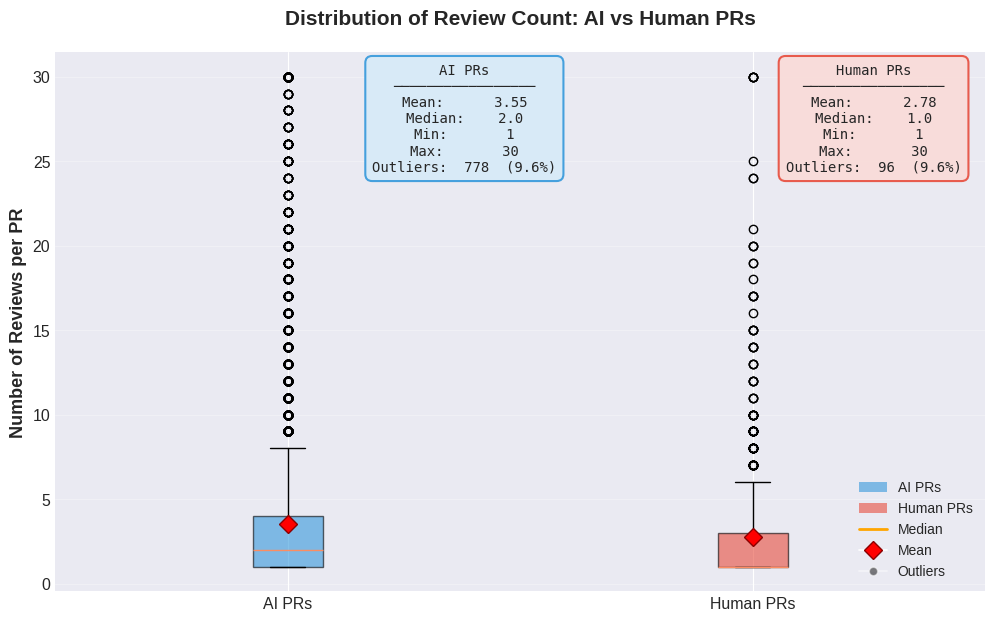

2. Creating box plot: Inline comments per PR...
   ✅ Saved: fig2_inline_comments_boxplot.png
3. Creating violin plot: Time to first review...
   Saved: fig3_time_to_review_violin.png
4. Creating stacked bar chart: First-pass approval rate...
   ✅ Saved: fig4_first_pass_approval_stacked.png
5. Creating grouped bar chart: Merge vs Rejection rates...
 Saved: fig5_merge_rejection_rates.png
6. Creating bar chart: Changes requested rate...
 Saved: fig6_changes_requested_rate.png
7. Creating scatter plot: Reviews vs Time to merge...
 Saved: fig7_reviews_vs_merge_time_scatter.png
8. Creating histogram: Review count distribution...
 Saved: fig8_review_count_histogram.png
9. Creating correlation heatmap: AI PRs...
 Saved: fig9_correlation_heatmap_ai.png
10. Creating correlation heatmap: Human PRs...
  Saved: fig10_correlation_heatmap_human.png
11. Creating CDF plot: Review count...
  Saved: fig11_review_count_cdf.png
12. Creating box plot: Time to merge for accepted PRs...
 Saved: fig12_time_to_

In [18]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for publication-quality figures
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
sns.set_context("paper", font_scale=1.3)

# ============================================================================
# LOAD DATA
# ============================================================================
print("Loading data...")


# Convert timestamps
ai_prs['created_at'] = pd.to_datetime(ai_prs['created_at'])
ai_prs['merged_at'] = pd.to_datetime(ai_prs['merged_at'])
ai_reviews['submitted_at'] = pd.to_datetime(ai_reviews['submitted_at'])

human_prs['created_at'] = pd.to_datetime(human_prs['created_at'])
human_prs['merged_at'] = pd.to_datetime(human_prs['merged_at'])
human_reviews['submitted_at'] = pd.to_datetime(human_reviews['submitted_at'])

print("Data loaded\n")

# ============================================================================
# PREPARE DATA FOR PLOTTING
# ============================================================================

# Reviews per PR
ai_reviews_per_pr = ai_reviews.groupby('pr_id').size()
human_reviews_per_pr = human_reviews.groupby('pr_id').size()

# Inline comments per PR
def get_inline_per_pr(pr_ids, reviews, review_comments):
    results = []
    for pr_id in pr_ids:
        pr_review_ids = reviews[reviews['pr_id'] == pr_id]['id'].values
        count = len(review_comments[review_comments['pull_request_review_id'].isin(pr_review_ids)])
        results.append(count)
    return np.array(results)

ai_inline = get_inline_per_pr(list(ai_pr_ids), ai_reviews, ai_review_comments)
human_inline = get_inline_per_pr(list(human_pr_ids), human_reviews, human_review_comments)

# Total comments per PR
def get_total_comments(pr_ids, reviews, review_comments, pr_comments):
    results = []
    for pr_id in pr_ids:
        review_body = len(reviews[(reviews['pr_id'] == pr_id) & (reviews['body'].notna())])
        pr_review_ids = reviews[reviews['pr_id'] == pr_id]['id'].values
        inline = len(review_comments[review_comments['pull_request_review_id'].isin(pr_review_ids)])
        discussion = len(pr_comments[pr_comments['pr_id'] == pr_id])
        results.append(review_body + inline + discussion)
    return np.array(results)

ai_total_comments = get_total_comments(list(ai_pr_ids), ai_reviews, ai_review_comments, ai_comments)
human_total_comments = get_total_comments(list(human_pr_ids), human_reviews, human_review_comments, human_comments)

# Time to first review
def get_time_to_first_review(prs, reviews):
    first_review = reviews.groupby('pr_id')['submitted_at'].min().reset_index()
    first_review.columns = ['pr_id', 'first_review_at']
    merged = prs.merge(first_review, left_on='id', right_on='pr_id', how='inner')
    merged['time_to_review_hours'] = (merged['first_review_at'] - merged['created_at']).dt.total_seconds() / 3600
    merged = merged[(merged['time_to_review_hours'] >= 0) & (merged['time_to_review_hours'] < 720)]
    return merged['time_to_review_hours'].values

ai_time_to_review = get_time_to_first_review(ai_prs, ai_reviews)
human_time_to_review = get_time_to_first_review(human_prs, human_reviews)

# Time to merge (for accepted PRs)
ai_merged = ai_prs[ai_prs['merged_at'].notna()].copy()
ai_merged['time_to_merge'] = (ai_merged['merged_at'] - ai_merged['created_at']).dt.total_seconds() / 3600
ai_time_to_merge = ai_merged['time_to_merge'][(ai_merged['time_to_merge'] >= 0) & (ai_merged['time_to_merge'] < 2000)].values

human_merged = human_prs[human_prs['merged_at'].notna()].copy()
human_merged['time_to_merge'] = (human_merged['merged_at'] - human_merged['created_at']).dt.total_seconds() / 3600
human_time_to_merge = human_merged['time_to_merge'][(human_merged['time_to_merge'] >= 0) & (human_merged['time_to_merge'] < 2000)].values

# Reviewers per PR
ai_reviewers_per_pr = ai_reviews.groupby('pr_id')['user'].nunique()
human_reviewers_per_pr = human_reviews.groupby('pr_id')['user'].nunique()

print("Data prepared for plotting\n")
print("="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

# ============================================================================
# FIGURE 1: BOX PLOTS - REVIEWS PER PR (with detailed statistics)
# ============================================================================
print("Creating box plot: Reviews per PR...")

fig, ax = plt.subplots(figsize=(12, 7))

# Prepare data
data_to_plot = [ai_reviews_per_pr.values, human_reviews_per_pr.values]

# Create box plot
colors = ['#3498db', '#e74c3c']
bp = ax.boxplot(data_to_plot,
                labels=['AI PRs', 'Human PRs'],
                patch_artist=True,
                showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='red',
                               markeredgecolor='darkred', markersize=9))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# ── compute outlier info ────────────────────────────────────────────────────
def outlier_stats(data):
    q1  = np.percentile(data, 25)
    q3  = np.percentile(data, 75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr
    n_out = int(np.sum((data > upper) | (data < lower)))
    return {
        'mean':    np.mean(data),
        'median':  np.median(data),
        'min':     int(np.min(data)),
        'max':     int(np.max(data)),
        'n_out':   n_out,
        'pct_out': n_out / len(data) * 100
    }

ai_s    = outlier_stats(ai_reviews_per_pr.values)
human_s = outlier_stats(human_reviews_per_pr.values)

# ── statistics table drawn as two text boxes ────────────────────────────────
ai_text = (
    "AI PRs\n"
    "─────────────────\n"
    f"Mean:      {ai_s['mean']:.2f}\n"
    f"Median:    {ai_s['median']:.1f}\n"
    f"Min:       {ai_s['min']}\n"
    f"Max:       {ai_s['max']}\n"
    f"Outliers:  {ai_s['n_out']:,}  ({ai_s['pct_out']:.1f}%)"
)

human_text = (
    "Human PRs\n"
    "─────────────────\n"
    f"Mean:      {human_s['mean']:.2f}\n"
    f"Median:    {human_s['median']:.1f}\n"
    f"Min:       {human_s['min']}\n"
    f"Max:       {human_s['max']}\n"
    f"Outliers:  {human_s['n_out']:,}  ({human_s['pct_out']:.1f}%)"
)

# Place the two stat boxes inside the plot, shifted right of centre
ax.text(0.44, 0.98, ai_text,
        transform=ax.transAxes,
        fontsize=10, verticalalignment='top', horizontalalignment='center',
        fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#d6eaf8',
                  edgecolor='#3498db', linewidth=1.5, alpha=0.9))

ax.text(0.88, 0.98, human_text,
        transform=ax.transAxes,
        fontsize=10, verticalalignment='top', horizontalalignment='center',
        fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#fadbd8',
                  edgecolor='#e74c3c', linewidth=1.5, alpha=0.9))

# ── legend for plot elements ─────────────────────────────────────────────────
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor='#3498db', alpha=0.6, label='AI PRs'),
    Patch(facecolor='#e74c3c', alpha=0.6, label='Human PRs'),
    Line2D([0], [0], color='orange',  linewidth=2,          label='Median'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='red',
           markeredgecolor='darkred', markersize=9,          label='Mean'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black',
           markersize=6, alpha=0.5,                          label='Outliers'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
          framealpha=0.9)

# ── labels & title ───────────────────────────────────────────────────────────
ax.set_ylabel('Number of Reviews per PR', fontsize=13, fontweight='bold')
ax.set_title('Distribution of Review Count: AI vs Human PRs',
             fontsize=15, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3)


plt.savefig('fig1_reviews_per_pr_boxplot.png', dpi=300, bbox_inches='tight')
print(" Saved: fig1_reviews_per_pr_boxplot.png")
plt.show()
plt.close()
# ============================================================================
# FIGURE 2: BOX PLOTS - INLINE COMMENTS PER PR
# ============================================================================
print("2. Creating box plot: Inline comments per PR...")

fig, ax = plt.subplots(figsize=(10, 6))

data_to_plot = [ai_inline, human_inline]
bp = ax.boxplot(data_to_plot,
                labels=['AI PRs', 'Human PRs'],
                patch_artist=True,
                showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='red', markersize=8))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel('Number of Inline Comments per PR', fontsize=13, fontweight='bold')
ax.set_title('Distribution of Inline Comments: AI vs Human PRs', fontsize=15, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3)

stats_text = f'AI: μ={ai_inline.mean():.2f}, Med={np.median(ai_inline):.1f}\nHuman: μ={human_inline.mean():.2f}, Med={np.median(human_inline):.1f}'
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('fig2_inline_comments_boxplot.png', dpi=300, bbox_inches='tight')
print("   ✅ Saved: fig2_inline_comments_boxplot.png")
plt.close()

# ============================================================================
# FIGURE 3: VIOLIN PLOT - TIME TO FIRST REVIEW
# ============================================================================
print("3. Creating violin plot: Time to first review...")

fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for violin plot
df_plot = pd.DataFrame({
    'Time (hours)': np.concatenate([ai_time_to_review, human_time_to_review]),
    'Type': ['AI']*len(ai_time_to_review) + ['Human']*len(human_time_to_review)
})

# Log transform for better visualization (highly skewed data)
df_plot['Log Time (hours)'] = np.log10(df_plot['Time (hours)'] + 1)

sns.violinplot(data=df_plot, x='Type', y='Log Time (hours)', palette=colors, ax=ax)

ax.set_ylabel('Time to First Review (log₁₀ hours)', fontsize=13, fontweight='bold')
ax.set_xlabel('PR Type', fontsize=13, fontweight='bold')
ax.set_title('Time to First Review Distribution: AI vs Human PRs', fontsize=15, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3)

stats_text = f'AI: μ={ai_time_to_review.mean():.1f}h, Med={np.median(ai_time_to_review):.1f}h\nHuman: μ={human_time_to_review.mean():.1f}h, Med={np.median(human_time_to_review):.1f}h'
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('fig3_time_to_review_violin.png', dpi=300, bbox_inches='tight')
print("   Saved: fig3_time_to_review_violin.png")
plt.close()

# ============================================================================
# FIGURE 4: STACKED BAR - FIRST-PASS APPROVAL RATE
# ============================================================================
print("4. Creating stacked bar chart: First-pass approval rate...")

# Calculate first-pass approvals
def get_first_pass(prs, reviews):
    first_reviews = reviews.sort_values('submitted_at').groupby('pr_id').first()
    results = pd.DataFrame()
    results['pr_id'] = prs['id']
    results['had_review'] = results['pr_id'].isin(first_reviews.index)
    results['approved'] = results['pr_id'].map(
        lambda x: first_reviews.loc[x, 'state'] == 'APPROVED' if x in first_reviews.index else False
    )
    return results

ai_first_pass = get_first_pass(ai_prs, ai_reviews)
human_first_pass = get_first_pass(human_prs, human_reviews)

ai_approved = ai_first_pass[ai_first_pass['had_review']]['approved'].sum()
ai_not_approved = ai_first_pass[ai_first_pass['had_review']]['approved'].count() - ai_approved
human_approved = human_first_pass[human_first_pass['had_review']]['approved'].sum()
human_not_approved = human_first_pass[human_first_pass['had_review']]['approved'].count() - human_approved

ai_total = ai_approved + ai_not_approved
human_total = human_approved + human_not_approved

fig, ax = plt.subplots(figsize=(10, 6))

categories = ['AI PRs', 'Human PRs']
approved_pcts = [ai_approved/ai_total*100, human_approved/human_total*100]
not_approved_pcts = [ai_not_approved/ai_total*100, human_not_approved/human_total*100]

x = np.arange(len(categories))
width = 0.5

p1 = ax.bar(x, approved_pcts, width, label='Approved', color='#2ecc71', alpha=0.8)
p2 = ax.bar(x, not_approved_pcts, width, bottom=approved_pcts, label='Not Approved', color='#e74c3c', alpha=0.8)

ax.set_ylabel('Percentage (%)', fontsize=13, fontweight='bold')
ax.set_title('First-Pass Approval Rate: AI vs Human PRs', fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.legend(loc='upper right', fontsize=11)
ax.set_ylim(0, 100)

# Add percentage labels
for i, (bar1, bar2) in enumerate(zip(p1, p2)):
    height1 = bar1.get_height()
    height2 = bar2.get_height()
    ax.text(bar1.get_x() + bar1.get_width()/2., height1/2, f'{height1:.1f}%',
            ha='center', va='center', fontsize=12, fontweight='bold', color='white')
    ax.text(bar2.get_x() + bar2.get_width()/2., height1 + height2/2, f'{height2:.1f}%',
            ha='center', va='center', fontsize=12, fontweight='bold', color='white')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_first_pass_approval_stacked.png', dpi=300, bbox_inches='tight')
print("   ✅ Saved: fig4_first_pass_approval_stacked.png")
plt.close()

# ============================================================================
# FIGURE 5: GROUPED BAR - MERGE VS REJECTION RATES
# ============================================================================
print("5. Creating grouped bar chart: Merge vs Rejection rates...")

ai_merge_rate = (ai_prs['merged_at'].notna().sum() / len(ai_prs)) * 100
human_merge_rate = (human_prs['merged_at'].notna().sum() / len(human_prs)) * 100

ai_reject_rate = ((ai_prs['state'] == 'closed') & (ai_prs['merged_at'].isna())).sum() / len(ai_prs) * 100
human_reject_rate = ((human_prs['state'] == 'closed') & (human_prs['merged_at'].isna())).sum() / len(human_prs) * 100

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(2)
width = 0.35

merge_bars = ax.bar(x - width/2, [ai_merge_rate, human_merge_rate], width,
                    label='Merged', color='#2ecc71', alpha=0.8)
reject_bars = ax.bar(x + width/2, [ai_reject_rate, human_reject_rate], width,
                     label='Rejected', color='#e74c3c', alpha=0.8)

ax.set_ylabel('Percentage (%)', fontsize=13, fontweight='bold')
ax.set_title('PR Outcomes: Merge vs Rejection Rates', fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(['AI PRs', 'Human PRs'], fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [merge_bars, reject_bars]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig5_merge_rejection_rates.png', dpi=300, bbox_inches='tight')
print(" Saved: fig5_merge_rejection_rates.png")
plt.close()

# ============================================================================
# FIGURE 6: BAR CHART - CHANGES REQUESTED RATE
# ============================================================================
print("6. Creating bar chart: Changes requested rate...")

def get_changes_rate(prs, reviews):
    changes_prs = reviews[reviews['state'] == 'CHANGES_REQUESTED']['pr_id'].unique()
    reviewed_prs = reviews['pr_id'].unique()
    return (len(changes_prs) / len(reviewed_prs)) * 100 if len(reviewed_prs) > 0 else 0

ai_changes_rate = get_changes_rate(ai_prs, ai_reviews)
human_changes_rate = get_changes_rate(human_prs, human_reviews)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(['AI PRs', 'Human PRs'], [ai_changes_rate, human_changes_rate],
              color=['#3498db', '#e74c3c'], alpha=0.8, width=0.5)

ax.set_ylabel('Percentage (%)', fontsize=13, fontweight='bold')
ax.set_title('PRs with Changes Requested: AI vs Human', fontsize=15, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.2,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add difference annotation
diff = ai_changes_rate - human_changes_rate
rel_diff = ((ai_changes_rate / human_changes_rate) - 1) * 100
ax.text(0.5, 0.95, f'Difference: +{diff:.1f} pp ({rel_diff:.0f}% relative increase)',
        transform=ax.transAxes, ha='center', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.savefig('fig6_changes_requested_rate.png', dpi=300, bbox_inches='tight')
print(" Saved: fig6_changes_requested_rate.png")
plt.close()

# ============================================================================
# FIGURE 7: SCATTER PLOT - REVIEWS VS TIME TO MERGE
# ============================================================================
print("7. Creating scatter plot: Reviews vs Time to merge...")

# Prepare data
def get_reviews_and_merge_time(prs, reviews):
    merged_prs = prs[prs['merged_at'].notna()].copy()
    merged_prs['time_to_merge'] = (merged_prs['merged_at'] - merged_prs['created_at']).dt.total_seconds() / 3600
    merged_prs = merged_prs[(merged_prs['time_to_merge'] >= 0) & (merged_prs['time_to_merge'] < 2000)]

    review_counts = reviews.groupby('pr_id').size().reset_index()
    review_counts.columns = ['id', 'review_count']

    data = merged_prs.merge(review_counts, on='id', how='inner')
    return data[data['review_count'] <= 20]  # Filter outliers

ai_scatter_data = get_reviews_and_merge_time(ai_prs, ai_reviews)
human_scatter_data = get_reviews_and_merge_time(human_prs, human_reviews)

fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(ai_scatter_data['review_count'], ai_scatter_data['time_to_merge'],
           alpha=0.3, s=30, color='#3498db', label='AI PRs')
ax.scatter(human_scatter_data['review_count'], human_scatter_data['time_to_merge'],
           alpha=0.3, s=30, color='#e74c3c', label='Human PRs')

# Add trend lines
z_ai = np.polyfit(ai_scatter_data['review_count'], ai_scatter_data['time_to_merge'], 1)
p_ai = np.poly1d(z_ai)
z_human = np.polyfit(human_scatter_data['review_count'], human_scatter_data['time_to_merge'], 1)
p_human = np.poly1d(z_human)

x_trend = np.linspace(0, 20, 100)
ax.plot(x_trend, p_ai(x_trend), "--", color='#3498db', linewidth=2, label='AI trend')
ax.plot(x_trend, p_human(x_trend), "--", color='#e74c3c', linewidth=2, label='Human trend')

ax.set_xlabel('Number of Reviews', fontsize=13, fontweight='bold')
ax.set_ylabel('Time to Merge (hours)', fontsize=13, fontweight='bold')
ax.set_title('Relationship: Reviews vs Time to Merge', fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig7_reviews_vs_merge_time_scatter.png', dpi=300, bbox_inches='tight')
print(" Saved: fig7_reviews_vs_merge_time_scatter.png")
plt.close()

# ============================================================================
# FIGURE 8: HISTOGRAM WITH OVERLAY - REVIEW COUNT DISTRIBUTION
# ============================================================================
print("8. Creating histogram: Review count distribution...")

fig, ax = plt.subplots(figsize=(12, 6))

bins = np.arange(0, 21, 1)
ax.hist(ai_reviews_per_pr.values, bins=bins, alpha=0.5, label='AI PRs',
        color='#3498db', edgecolor='black', density=True)
ax.hist(human_reviews_per_pr.values, bins=bins, alpha=0.5, label='Human PRs',
        color='#e74c3c', edgecolor='black', density=True)

ax.set_xlabel('Number of Reviews per PR', fontsize=13, fontweight='bold')
ax.set_ylabel('Density', fontsize=13, fontweight='bold')
ax.set_title('Distribution of Review Count: AI vs Human PRs', fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.set_xlim(0, 20)

plt.tight_layout()
plt.savefig('fig8_review_count_histogram.png', dpi=300, bbox_inches='tight')
print(" Saved: fig8_review_count_histogram.png")
plt.close()

# ============================================================================
# FIGURE 9: CORRELATION HEATMAP - AI PRs
# ============================================================================
print("9. Creating correlation heatmap: AI PRs...")

# Prepare correlation data
ai_corr_data = pd.DataFrame({
    'Reviews': ai_reviews_per_pr,
    'Inline_Comments': pd.Series(ai_inline, index=list(ai_pr_ids)),
    'Total_Comments': pd.Series(ai_total_comments, index=list(ai_pr_ids)),
    'Reviewers': ai_reviewers_per_pr
}).fillna(0)

# Add merge time for merged PRs
ai_merged_times = ai_merged.set_index('id')['time_to_merge']
ai_corr_data['Time_to_Merge'] = ai_merged_times
ai_corr_data = ai_corr_data.dropna()

corr_matrix = ai_corr_data.corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax,
            vmin=-1, vmax=1)

ax.set_title('Correlation Matrix: AI PRs Metrics (Spearman)', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('fig9_correlation_heatmap_ai.png', dpi=300, bbox_inches='tight')
print(" Saved: fig9_correlation_heatmap_ai.png")
plt.close()

# ============================================================================
# FIGURE 10: CORRELATION HEATMAP - HUMAN PRs
# ============================================================================
print("10. Creating correlation heatmap: Human PRs...")

human_corr_data = pd.DataFrame({
    'Reviews': human_reviews_per_pr,
    'Inline_Comments': pd.Series(human_inline, index=list(human_pr_ids)),
    'Total_Comments': pd.Series(human_total_comments, index=list(human_pr_ids)),
    'Reviewers': human_reviewers_per_pr
}).fillna(0)

human_merged_times = human_merged.set_index('id')['time_to_merge']
human_corr_data['Time_to_Merge'] = human_merged_times
human_corr_data = human_corr_data.dropna()

corr_matrix_human = human_corr_data.corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix_human, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax,
            vmin=-1, vmax=1)

ax.set_title('Correlation Matrix: Human PRs Metrics (Spearman)', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('fig10_correlation_heatmap_human.png', dpi=300, bbox_inches='tight')
print("  Saved: fig10_correlation_heatmap_human.png")
plt.close()

# ============================================================================
# FIGURE 11: CDF PLOT - REVIEW COUNT
# ============================================================================
print("11. Creating CDF plot: Review count...")

fig, ax = plt.subplots(figsize=(12, 6))

# Sort data for CDF
ai_sorted = np.sort(ai_reviews_per_pr.values)
human_sorted = np.sort(human_reviews_per_pr.values)

# Calculate CDF
ai_cdf = np.arange(1, len(ai_sorted) + 1) / len(ai_sorted)
human_cdf = np.arange(1, len(human_sorted) + 1) / len(human_sorted)

ax.plot(ai_sorted, ai_cdf, label='AI PRs', color='#3498db', linewidth=2)
ax.plot(human_sorted, human_cdf, label='Human PRs', color='#e74c3c', linewidth=2)

ax.set_xlabel('Number of Reviews per PR', fontsize=13, fontweight='bold')
ax.set_ylabel('Cumulative Probability', fontsize=13, fontweight='bold')
ax.set_title('Cumulative Distribution: Review Count', fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
ax.set_xlim(0, 20)

# Add median lines
ax.axvline(np.median(ai_sorted), color='#3498db', linestyle='--', alpha=0.5, label=f'AI median: {np.median(ai_sorted):.1f}')
ax.axvline(np.median(human_sorted), color='#e74c3c', linestyle='--', alpha=0.5, label=f'Human median: {np.median(human_sorted):.1f}')

plt.tight_layout()
plt.savefig('fig11_review_count_cdf.png', dpi=300, bbox_inches='tight')
print("  Saved: fig11_review_count_cdf.png")
plt.close()

# ============================================================================
# FIGURE 12: BOX PLOT - TIME TO MERGE (ACCEPTED PRs)
# ============================================================================
print("12. Creating box plot: Time to merge for accepted PRs...")

fig, ax = plt.subplots(figsize=(10, 6))

data_to_plot = [ai_time_to_merge, human_time_to_merge]
bp = ax.boxplot(data_to_plot,
                labels=['AI PRs', 'Human PRs'],
                patch_artist=True,
                showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='red', markersize=8))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel('Time to Merge (hours)', fontsize=13, fontweight='bold')
ax.set_title('Time to Merge for Accepted PRs: AI vs Human', fontsize=15, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3)

stats_text = f'AI: μ={ai_time_to_merge.mean():.1f}h, Med={np.median(ai_time_to_merge):.1f}h\nHuman: μ={human_time_to_merge.mean():.1f}h, Med={np.median(human_time_to_merge):.1f}h'
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Add difference annotation
diff_pct = ((human_time_to_merge.mean() - ai_time_to_merge.mean()) / human_time_to_merge.mean()) * 100
ax.text(0.5, 0.90, f'AI PRs merge {diff_pct:.1f}% faster',
        transform=ax.transAxes, ha='center', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.savefig('fig12_time_to_merge_boxplot.png', dpi=300, bbox_inches='tight')
print(" Saved: fig12_time_to_merge_boxplot.png")
plt.close()

# ============================================================================
# FIGURE 13: MULTI-PANEL COMPARISON
# ============================================================================
print("13. Creating multi-panel summary figure...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Reviews per PR
data = [ai_reviews_per_pr.values, human_reviews_per_pr.values]
bp = axes[0, 0].boxplot(data, labels=['AI', 'Human'], patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0, 0].set_ylabel('Reviews per PR', fontweight='bold')
axes[0, 0].set_title('A) Review Count', fontweight='bold', fontsize=13)
axes[0, 0].grid(axis='y', alpha=0.3)

# Panel 2: First-pass approval
approved_rates = [ai_approved/ai_total*100, human_approved/human_total*100]
bars = axes[0, 1].bar(['AI', 'Human'], approved_rates, color=colors, alpha=0.8)
axes[0, 1].set_ylabel('Approval Rate (%)', fontweight='bold')
axes[0, 1].set_title('B) First-Pass Approval', fontweight='bold', fontsize=13)
axes[0, 1].grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

# Panel 3: Time to first review (log scale)
data = [np.log10(ai_time_to_review + 1), np.log10(human_time_to_review + 1)]
bp = axes[1, 0].boxplot(data, labels=['AI', 'Human'], patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1, 0].set_ylabel('Time to Review (log₁₀ hours)', fontweight='bold')
axes[1, 0].set_title('C) Time to First Review', fontweight='bold', fontsize=13)
axes[1, 0].grid(axis='y', alpha=0.3)

# Panel 4: Merge rates
merge_rates = [ai_merge_rate, human_merge_rate]
bars = axes[1, 1].bar(['AI', 'Human'], merge_rates, color=colors, alpha=0.8)
axes[1, 1].set_ylabel('Merge Rate (%)', fontweight='bold')
axes[1, 1].set_title('D) PR Acceptance', fontweight='bold', fontsize=13)
axes[1, 1].grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Key Metrics Summary: AI vs Human PRs', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('fig13_summary_multipanel.png', dpi=300, bbox_inches='tight')
print(" Saved: fig13_summary_multipanel.png")
plt.close()

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*80)
print("ALL VISUALIZATIONS COMPLETE!")
print("="*80)
print("\nGenerated 13 figures:")
print("  1. fig1_reviews_per_pr_boxplot.png")
print("  2. fig2_inline_comments_boxplot.png")
print("  3. fig3_time_to_review_violin.png")
print("  4. fig4_first_pass_approval_stacked.png")
print("  5. fig5_merge_rejection_rates.png")
print("  6. fig6_changes_requested_rate.png")
print("  7. fig7_reviews_vs_merge_time_scatter.png")
print("  8. fig8_review_count_histogram.png")
print("  9. fig9_correlation_heatmap_ai.png")
print(" 10. fig10_correlation_heatmap_human.png")
print(" 11. fig11_review_count_cdf.png")
print(" 12. fig12_time_to_merge_boxplot.png")
print(" 13. fig13_summary_multipanel.png")

print("\n💡 RECOMMENDATIONS FOR YOUR PAPER:")
print("\nUse these figures:")
print("  - Fig 13 (multi-panel): Perfect for main results overview")
print("  - Fig 4 (first-pass approval): Your strongest finding!")
print("  - Fig 7 (scatter): Shows relationship between metrics")
print("  - Fig 9/10 (heatmaps): Shows metric correlations")

print("\nSupplementary material:")
print("  - Remaining figures as supporting evidence")
print("  - All figures are publication-ready (300 DPI)")

Creating box plot: Reviews per PR...
Saved: fig1_reviews_per_pr_boxplot.png


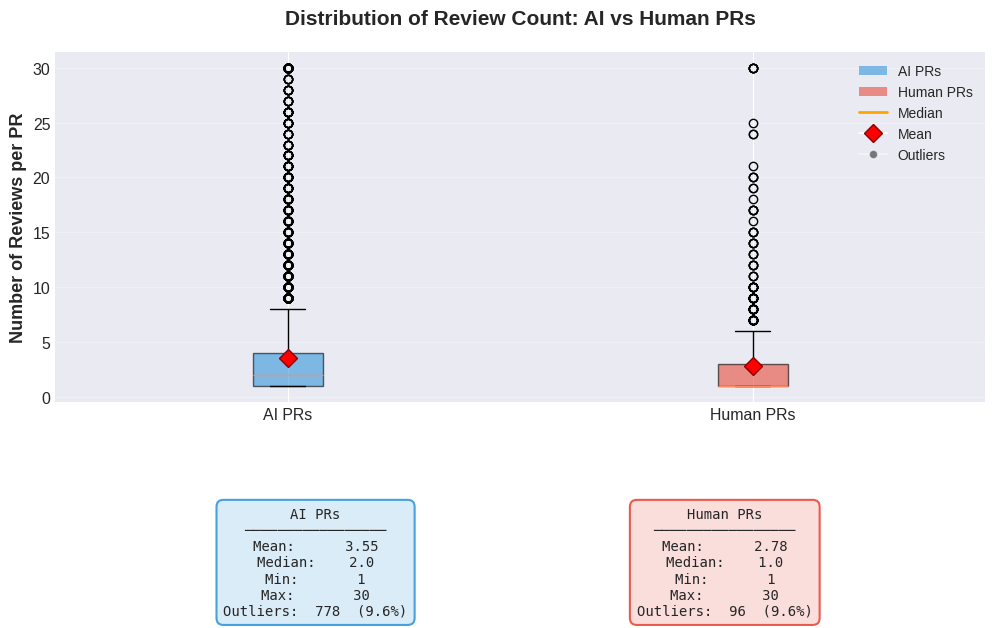

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

# ============================================================================
# FIGURE 1: BOX PLOTS - REVIEWS PER PR (with detailed statistics)
# ============================================================================
print("Creating box plot: Reviews per PR...")

fig, ax = plt.subplots(figsize=(12, 7))

# Prepare data
data_to_plot = [ai_reviews_per_pr.values, human_reviews_per_pr.values]

# Create box plot
colors = ['#3498db', '#e74c3c']
bp = ax.boxplot(data_to_plot,
                labels=['AI PRs', 'Human PRs'],
                patch_artist=True,
                showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='red',
                               markeredgecolor='darkred', markersize=9))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# ── compute outlier info ────────────────────────────────────────────────────
def outlier_stats(data):
    q1  = np.percentile(data, 25)
    q3  = np.percentile(data, 75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr
    n_out = int(np.sum((data > upper) | (data < lower)))
    return {
        'mean':    np.mean(data),
        'median':  np.median(data),
        'min':     int(np.min(data)),
        'max':     int(np.max(data)),
        'n_out':   n_out,
        'pct_out': n_out / len(data) * 100
    }

ai_s    = outlier_stats(ai_reviews_per_pr.values)
human_s = outlier_stats(human_reviews_per_pr.values)

# ── statistics table drawn as two text boxes ────────────────────────────────
ai_text = (
    "AI PRs\n"
    "─────────────────\n"
    f"Mean:      {ai_s['mean']:.2f}\n"
    f"Median:    {ai_s['median']:.1f}\n"
    f"Min:       {ai_s['min']}\n"
    f"Max:       {ai_s['max']}\n"
    f"Outliers:  {ai_s['n_out']:,}  ({ai_s['pct_out']:.1f}%)"
)

human_text = (
    "Human PRs\n"
    "─────────────────\n"
    f"Mean:      {human_s['mean']:.2f}\n"
    f"Median:    {human_s['median']:.1f}\n"
    f"Min:       {human_s['min']}\n"
    f"Max:       {human_s['max']}\n"
    f"Outliers:  {human_s['n_out']:,}  ({human_s['pct_out']:.1f}%)"
)

# Place the two stat boxes side-by-side below the plot
ax.text(0.28, -0.30, ai_text,
        transform=ax.transAxes,
        fontsize=10, verticalalignment='top', horizontalalignment='center',
        fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#d6eaf8',
                  edgecolor='#3498db', linewidth=1.5, alpha=0.9))

ax.text(0.72, -0.30, human_text,
        transform=ax.transAxes,
        fontsize=10, verticalalignment='top', horizontalalignment='center',
        fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#fadbd8',
                  edgecolor='#e74c3c', linewidth=1.5, alpha=0.9))

# ── legend for plot elements ─────────────────────────────────────────────────
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor='#3498db', alpha=0.6, label='AI PRs'),
    Patch(facecolor='#e74c3c', alpha=0.6, label='Human PRs'),
    Line2D([0], [0], color='orange',  linewidth=2,          label='Median'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='red',
           markeredgecolor='darkred', markersize=9,          label='Mean'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black',
           markersize=6, alpha=0.5,                          label='Outliers'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10,
          framealpha=0.9)

# ── labels & title ───────────────────────────────────────────────────────────
ax.set_ylabel('Number of Reviews per PR', fontsize=13, fontweight='bold')
ax.set_title('Distribution of Review Count: AI vs Human PRs',
             fontsize=15, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3)

# Leave extra space at the bottom for the stat boxes
plt.subplots_adjust(bottom=0.38)

plt.savefig('fig1_reviews_per_pr_boxplot.png', dpi=300, bbox_inches='tight')
print("Saved: fig1_reviews_per_pr_boxplot.png")
plt.show()
plt.close()

In [20]:
"""
DETAILED BOX PLOT ANALYSIS: AI PR REVIEW COUNTS WITH OUTLIER DETECTION
======================================================================

This script creates a comprehensive box plot showing the distribution of
review counts for AI PRs, identifies outliers, and provides detailed statistics.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.3)

# ============================================================================
# LOAD DATA
# ============================================================================
print("Loading AI PR data...")

ai_prs = pd.read_parquet("hf://datasets/hao-li/AIDev/pull_request.parquet")
ai_reviews = pd.read_parquet("hf://datasets/hao-li/AIDev/pr_reviews.parquet")

# Filter reviews to match PRs
ai_pr_ids = set(ai_prs['id'].unique())
ai_reviews = ai_reviews[ai_reviews['pr_id'].isin(ai_pr_ids)].copy()

print(f" Loaded {len(ai_prs):,} AI PRs")
print(f" Loaded {len(ai_reviews):,} reviews\n")

# ============================================================================
# CALCULATE REVIEWS PER PR
# ============================================================================
print("Calculating reviews per PR...")

reviews_per_pr = ai_reviews.groupby('pr_id').size()

print(f"Total PRs with reviews: {len(reviews_per_pr):,}\n")

# ============================================================================
# CALCULATE STATISTICS AND IDENTIFY OUTLIERS
# ============================================================================
print("="*80)
print("DESCRIPTIVE STATISTICS")
print("="*80)

# Basic statistics
mean_reviews = reviews_per_pr.mean()
median_reviews = reviews_per_pr.median()
std_reviews = reviews_per_pr.std()
min_reviews = reviews_per_pr.min()
max_reviews = reviews_per_pr.max()

print(f"Mean:     {mean_reviews:.2f} reviews")
print(f"Median:   {median_reviews:.1f} reviews")
print(f"Std Dev:  {std_reviews:.2f}")
print(f"Min:      {min_reviews:.0f} reviews")
print(f"Max:      {max_reviews:.0f} reviews")

# Quartiles
q1 = reviews_per_pr.quantile(0.25)
q3 = reviews_per_pr.quantile(0.75)
iqr = q3 - q1

print(f"\nQuartiles:")
print(f"Q1 (25%): {q1:.1f} reviews")
print(f"Q2 (50%): {median_reviews:.1f} reviews (median)")
print(f"Q3 (75%): {q3:.1f} reviews")
print(f"IQR:      {iqr:.1f}")

# Outlier detection using IQR method
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = reviews_per_pr[(reviews_per_pr < lower_bound) | (reviews_per_pr > upper_bound)]
outliers_upper = reviews_per_pr[reviews_per_pr > upper_bound]
outliers_lower = reviews_per_pr[reviews_per_pr < lower_bound]

print(f"\n" + "="*80)
print("OUTLIER DETECTION (IQR Method)")
print("="*80)
print(f"Lower bound: {lower_bound:.1f} reviews")
print(f"Upper bound: {upper_bound:.1f} reviews")
print(f"\nTotal outliers: {len(outliers):,} PRs ({len(outliers)/len(reviews_per_pr)*100:.1f}%)")
print(f"  Upper outliers (>{upper_bound:.1f}): {len(outliers_upper):,} PRs")
print(f"  Lower outliers (<{lower_bound:.1f}): {len(outliers_lower):,} PRs")

# Show extreme outliers
extreme_outliers = reviews_per_pr[reviews_per_pr > q3 + 3 * iqr]
print(f"\nExtreme outliers (>Q3 + 3*IQR): {len(extreme_outliers):,} PRs")
if len(extreme_outliers) > 0:
    print(f"  Max extreme: {extreme_outliers.max():.0f} reviews")

# Distribution of review counts
print(f"\n" + "="*80)
print("DISTRIBUTION OF REVIEW COUNTS")
print("="*80)

value_counts = reviews_per_pr.value_counts().sort_index()
print(f"\n{'Reviews':<10} {'Count':<10} {'Percentage':<12} {'Cumulative %'}")
print("-" * 50)

cumulative = 0
for reviews, count in value_counts.head(20).items():
    pct = count / len(reviews_per_pr) * 100
    cumulative += pct
    print(f"{reviews:<10} {count:<10,} {pct:<11.1f}% {cumulative:>6.1f}%")

if len(value_counts) > 20:
    remaining = len(reviews_per_pr) - value_counts.head(20).sum()
    pct_remaining = remaining / len(reviews_per_pr) * 100
    print(f"{'21+':.<10} {remaining:<10,} {pct_remaining:<11.1f}% {100.0:>6.1f}%")

# ============================================================================
# CREATE DETAILED BOX PLOT
# ============================================================================
print(f"\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

# Figure 1: Standard box plot with outliers
print("\n1. Creating standard box plot with outliers...")

fig, ax = plt.subplots(figsize=(12, 8))

# Create box plot
bp = ax.boxplot([reviews_per_pr.values],
                vert=True,
                patch_artist=True,
                showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='red', markersize=10, label='Mean'),
                medianprops=dict(linewidth=2, color='darkblue'),
                boxprops=dict(facecolor='#3498db', alpha=0.7, linewidth=1.5),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor='red', markersize=5,
                               linestyle='none', alpha=0.5, label='Outliers'))

ax.set_ylabel('Number of Reviews per PR', fontsize=14, fontweight='bold')
ax.set_title('Distribution of Review Counts for AI PRs\n(with Outlier Detection)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticklabels(['AI PRs'], fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add statistics box
stats_text = f"""Statistics:
Mean: {mean_reviews:.2f}
Median: {median_reviews:.1f}
Std Dev: {std_reviews:.2f}
Q1: {q1:.1f}
Q3: {q3:.1f}
IQR: {iqr:.1f}

Outliers: {len(outliers):,} ({len(outliers)/len(reviews_per_pr)*100:.1f}%)
Max: {max_reviews:.0f} reviews"""

ax.text(1.15, 0.5, stats_text, transform=ax.transAxes,
        fontsize=11, verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        family='monospace')

# Add horizontal reference lines
ax.axhline(y=mean_reviews, color='red', linestyle='--', alpha=0.5, linewidth=1, label='Mean')
ax.axhline(y=median_reviews, color='darkblue', linestyle='--', alpha=0.5, linewidth=1, label='Median')
ax.axhline(y=upper_bound, color='orange', linestyle=':', alpha=0.7, linewidth=1.5, label='Outlier Threshold')

ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('boxplot_ai_reviews_with_outliers.png', dpi=300, bbox_inches='tight')
print("   Saved: boxplot_ai_reviews_with_outliers.png")
plt.close()

# ============================================================================
# Figure 2: Box plot WITHOUT outliers (zoomed in)
# ============================================================================
print("2. Creating zoomed box plot (without outliers)...")

fig, ax = plt.subplots(figsize=(12, 8))

# Remove outliers for visualization
non_outliers = reviews_per_pr[(reviews_per_pr >= lower_bound) & (reviews_per_pr <= upper_bound)]

bp = ax.boxplot([non_outliers.values],
                vert=True,
                patch_artist=True,
                showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='red', markersize=10),
                medianprops=dict(linewidth=2, color='darkblue'),
                boxprops=dict(facecolor='#2ecc71', alpha=0.7, linewidth=1.5),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5))

ax.set_ylabel('Number of Reviews per PR', fontsize=14, fontweight='bold')
ax.set_title('Distribution of Review Counts for AI PRs\n(Outliers Removed for Clarity)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticklabels(['AI PRs (Non-outliers)'], fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Statistics for non-outliers
stats_text = f"""Non-outlier Statistics:
Count: {len(non_outliers):,} ({len(non_outliers)/len(reviews_per_pr)*100:.1f}%)
Mean: {non_outliers.mean():.2f}
Median: {non_outliers.median():.1f}
Std Dev: {non_outliers.std():.2f}
Min: {non_outliers.min():.0f}
Max: {non_outliers.max():.0f}

Range: {lower_bound:.1f} - {upper_bound:.1f}"""

ax.text(1.15, 0.5, stats_text, transform=ax.transAxes,
        fontsize=11, verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8),
        family='monospace')

plt.tight_layout()
plt.savefig('boxplot_ai_reviews_no_outliers.png', dpi=300, bbox_inches='tight')
print("   Saved: boxplot_ai_reviews_no_outliers.png")
plt.close()

# ============================================================================
# Figure 3: Histogram with outliers highlighted
# ============================================================================
print("3. Creating histogram with outliers highlighted...")

fig, ax = plt.subplots(figsize=(14, 8))

# Plot histogram
n, bins, patches = ax.hist(reviews_per_pr.values, bins=range(0, int(max_reviews)+2),
                           alpha=0.7, color='#3498db', edgecolor='black', linewidth=0.5)

# Highlight outliers in red
for i, patch in enumerate(patches):
    if bins[i] > upper_bound or bins[i] < lower_bound:
        patch.set_facecolor('red')
        patch.set_alpha(0.9)

ax.set_xlabel('Number of Reviews per PR', fontsize=14, fontweight='bold')
ax.set_ylabel('Frequency (Number of PRs)', fontsize=14, fontweight='bold')
ax.set_title('Distribution of Review Counts with Outliers Highlighted',
             fontsize=16, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add vertical lines
ax.axvline(x=mean_reviews, color='red', linestyle='--', linewidth=2, label=f'Mean ({mean_reviews:.2f})')
ax.axvline(x=median_reviews, color='blue', linestyle='--', linewidth=2, label=f'Median ({median_reviews:.1f})')
ax.axvline(x=upper_bound, color='orange', linestyle=':', linewidth=2.5, label=f'Outlier Threshold ({upper_bound:.1f})')

ax.legend(fontsize=12)

# Add text annotation
ax.text(0.98, 0.98, f'Outliers (red bars): {len(outliers):,} PRs\nNormal range (blue): {len(non_outliers):,} PRs',
        transform=ax.transAxes, fontsize=11, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.savefig('histogram_ai_reviews_outliers_highlighted.png', dpi=300, bbox_inches='tight')
print("   Saved: histogram_ai_reviews_outliers_highlighted.png")
plt.close()

# ============================================================================
# Figure 4: Combined view (Box + Violin)
# ============================================================================
print("4. Creating combined box + violin plot...")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: Box plot
bp = axes[0].boxplot([reviews_per_pr.values],
                     vert=True,
                     patch_artist=True,
                     showmeans=True,
                     meanprops=dict(marker='D', markerfacecolor='red', markersize=10),
                     medianprops=dict(linewidth=2, color='darkblue'),
                     boxprops=dict(facecolor='#3498db', alpha=0.7, linewidth=1.5),
                     whiskerprops=dict(linewidth=1.5),
                     capprops=dict(linewidth=1.5),
                     flierprops=dict(marker='o', markerfacecolor='red', markersize=4,
                                    linestyle='none', alpha=0.3))

axes[0].set_ylabel('Number of Reviews per PR', fontsize=13, fontweight='bold')
axes[0].set_title('A) Box Plot', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['AI PRs'])
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(y=upper_bound, color='orange', linestyle=':', alpha=0.7, linewidth=1.5)

# Right: Violin plot
parts = axes[1].violinplot([reviews_per_pr.values], positions=[1], showmeans=True, showmedians=True)

# Customize violin plot colors
for pc in parts['bodies']:
    pc.set_facecolor('#3498db')
    pc.set_alpha(0.7)

axes[1].set_ylabel('Number of Reviews per PR', fontsize=13, fontweight='bold')
axes[1].set_title('B) Violin Plot (shows distribution density)', fontsize=14, fontweight='bold')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['AI PRs'])
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(y=upper_bound, color='orange', linestyle=':', alpha=0.7, linewidth=1.5, label='Outlier threshold')

plt.suptitle('Review Count Distribution: Two Perspectives', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('combined_box_violin_plot.png', dpi=300, bbox_inches='tight')
print("   Saved: combined_box_violin_plot.png")
plt.close()

# ============================================================================
# IDENTIFY AND SAVE TOP OUTLIERS
# ============================================================================
print(f"\n" + "="*80)
print("TOP OUTLIERS (PRs with most reviews)")
print("="*80)

top_outliers = reviews_per_pr.nlargest(20)
print(f"\n{'Rank':<6} {'PR ID':<20} {'Number of Reviews'}")
print("-" * 50)
for rank, (pr_id, review_count) in enumerate(top_outliers.items(), 1):
    print(f"{rank:<6} {pr_id:<20} {review_count:>6} reviews")

# Save outliers to CSV
outlier_df = pd.DataFrame({
    'pr_id': outliers.index,
    'review_count': outliers.values,
    'outlier_type': ['Upper' if x > upper_bound else 'Lower' for x in outliers.values]
}).sort_values('review_count', ascending=False)

outlier_df.to_csv('ai_pr_review_outliers.csv', index=False)
print(f"\nSaved outlier list to: ai_pr_review_outliers.csv")

# Save all review counts
all_reviews_df = pd.DataFrame({
    'pr_id': reviews_per_pr.index,
    'review_count': reviews_per_pr.values
}).sort_values('review_count', ascending=False)

all_reviews_df.to_csv('ai_pr_all_review_counts.csv', index=False)
print(f"Saved all review counts to: ai_pr_all_review_counts.csv")

# ============================================================================
# SUMMARY STATISTICS TABLE
# ============================================================================
print(f"\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)

summary_stats = pd.DataFrame({
    'Statistic': ['Count', 'Mean', 'Median', 'Std Dev', 'Min', 'Max',
                  'Q1', 'Q3', 'IQR', 'Lower Bound', 'Upper Bound',
                  'Outliers', 'Outlier %'],
    'Value': [len(reviews_per_pr), mean_reviews, median_reviews, std_reviews,
              min_reviews, max_reviews, q1, q3, iqr, lower_bound, upper_bound,
              len(outliers), len(outliers)/len(reviews_per_pr)*100]
})

print(summary_stats.to_string(index=False))

summary_stats.to_csv('ai_pr_review_summary_stats.csv', index=False)
print(f"\nSaved summary statistics to: ai_pr_review_summary_stats.csv")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)

print("\nGenerated Files:")
print("   1. boxplot_ai_reviews_with_outliers.png")
print("   2. boxplot_ai_reviews_no_outliers.png")
print("   3. histogram_ai_reviews_outliers_highlighted.png")
print("   4. combined_box_violin_plot.png")
print("   5. ai_pr_review_outliers.csv")
print("   6. ai_pr_all_review_counts.csv")
print("   7. ai_pr_review_summary_stats.csv")

print("\n Key Findings:")
print(f"   • Most PRs have {median_reviews:.0f} reviews (median)")
print(f"   • Average is {mean_reviews:.2f} reviews (pulled up by outliers)")
print(f"   • {len(outliers):,} PRs ({len(outliers)/len(reviews_per_pr)*100:.1f}%) are outliers")
print(f"   • Outliers have >{upper_bound:.1f} reviews")
print(f"   • Maximum: {max_reviews:.0f} reviews on a single PR!")

print("\n Interpretation:")
if len(outliers)/len(reviews_per_pr) > 0.15:
    print("     High outlier rate suggests some PRs require extensive review")
    print("      This could indicate quality issues or complex changes")
else:
    print("    Outlier rate is reasonable for this type of data")

print(f"\n   • The difference between mean ({mean_reviews:.2f}) and median ({median_reviews:.1f})")
print(f"     shows the distribution is RIGHT-SKEWED (long tail of high review counts)")

Loading AI PR data...
 Loaded 33,596 AI PRs
 Loaded 28,875 reviews

Calculating reviews per PR...
Total PRs with reviews: 8,140

DESCRIPTIVE STATISTICS
Mean:     3.55 reviews
Median:   2.0 reviews
Std Dev:  4.72
Min:      1 reviews
Max:      30 reviews

Quartiles:
Q1 (25%): 1.0 reviews
Q2 (50%): 2.0 reviews (median)
Q3 (75%): 4.0 reviews
IQR:      3.0

OUTLIER DETECTION (IQR Method)
Lower bound: -3.5 reviews
Upper bound: 8.5 reviews

Total outliers: 778 PRs (9.6%)
  Upper outliers (>8.5): 778 PRs
  Lower outliers (<-3.5): 0 PRs

Extreme outliers (>Q3 + 3*IQR): 367 PRs
  Max extreme: 30 reviews

DISTRIBUTION OF REVIEW COUNTS

Reviews    Count      Percentage   Cumulative %
--------------------------------------------------
1          3,568      43.8       %   43.8%
2          1,535      18.9       %   62.7%
3          830        10.2       %   72.9%
4          511        6.3        %   79.2%
5          363        4.5        %   83.6%
6          234        2.9        %   86.5%
7         

In [21]:

# ============================================================================
# CALCULATE REVIEWS PER PR
# ============================================================================
print("Calculating reviews per PR...")

reviews_per_pr = human_reviews.groupby('pr_id').size()

print(f"Total PRs with reviews: {len(reviews_per_pr):,}\n")

# ============================================================================
# CALCULATE STATISTICS AND IDENTIFY OUTLIERS
# ============================================================================
print("="*80)
print("DESCRIPTIVE STATISTICS")
print("="*80)

# Basic statistics
mean_reviews = reviews_per_pr.mean()
median_reviews = reviews_per_pr.median()
std_reviews = reviews_per_pr.std()
min_reviews = reviews_per_pr.min()
max_reviews = reviews_per_pr.max()

print(f"Mean:     {mean_reviews:.2f} reviews")
print(f"Median:   {median_reviews:.1f} reviews")
print(f"Std Dev:  {std_reviews:.2f}")
print(f"Min:      {min_reviews:.0f} reviews")
print(f"Max:      {max_reviews:.0f} reviews")

# Quartiles
q1 = reviews_per_pr.quantile(0.25)
q3 = reviews_per_pr.quantile(0.75)
iqr = q3 - q1

print(f"\nQuartiles:")
print(f"Q1 (25%): {q1:.1f} reviews")
print(f"Q2 (50%): {median_reviews:.1f} reviews (median)")
print(f"Q3 (75%): {q3:.1f} reviews")
print(f"IQR:      {iqr:.1f}")

# Outlier detection using IQR method
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = reviews_per_pr[(reviews_per_pr < lower_bound) | (reviews_per_pr > upper_bound)]
outliers_upper = reviews_per_pr[reviews_per_pr > upper_bound]
outliers_lower = reviews_per_pr[reviews_per_pr < lower_bound]

print(f"\n" + "="*80)
print("OUTLIER DETECTION (IQR Method)")
print("="*80)
print(f"Lower bound: {lower_bound:.1f} reviews")
print(f"Upper bound: {upper_bound:.1f} reviews")
print(f"\nTotal outliers: {len(outliers):,} PRs ({len(outliers)/len(reviews_per_pr)*100:.1f}%)")
print(f"  Upper outliers (>{upper_bound:.1f}): {len(outliers_upper):,} PRs")
print(f"  Lower outliers (<{lower_bound:.1f}): {len(outliers_lower):,} PRs")

# Show extreme outliers
extreme_outliers = reviews_per_pr[reviews_per_pr > q3 + 3 * iqr]
print(f"\nExtreme outliers (>Q3 + 3*IQR): {len(extreme_outliers):,} PRs")
if len(extreme_outliers) > 0:
    print(f"  Max extreme: {extreme_outliers.max():.0f} reviews")

# Distribution of review counts
print(f"\n" + "="*80)
print("DISTRIBUTION OF REVIEW COUNTS")
print("="*80)

value_counts = reviews_per_pr.value_counts().sort_index()
print(f"\n{'Reviews':<10} {'Count':<10} {'Percentage':<12} {'Cumulative %'}")
print("-" * 50)

cumulative = 0
for reviews, count in value_counts.head(20).items():
    pct = count / len(reviews_per_pr) * 100
    cumulative += pct
    print(f"{reviews:<10} {count:<10,} {pct:<11.1f}% {cumulative:>6.1f}%")

if len(value_counts) > 20:
    remaining = len(reviews_per_pr) - value_counts.head(20).sum()
    pct_remaining = remaining / len(reviews_per_pr) * 100
    print(f"{'21+':.<10} {remaining:<10,} {pct_remaining:<11.1f}% {100.0:>6.1f}%")

# ============================================================================
# CREATE DETAILED BOX PLOT
# ============================================================================
print(f"\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

# Figure 1: Standard box plot with outliers
print("\n1. Creating standard box plot with outliers...")

fig, ax = plt.subplots(figsize=(12, 8))

# Create box plot
bp = ax.boxplot([reviews_per_pr.values],
                vert=True,
                patch_artist=True,
                showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='red', markersize=10, label='Mean'),
                medianprops=dict(linewidth=2, color='darkblue'),
                boxprops=dict(facecolor='#3498db', alpha=0.7, linewidth=1.5),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor='red', markersize=5,
                               linestyle='none', alpha=0.5, label='Outliers'))

ax.set_ylabel('Number of Reviews per PR', fontsize=14, fontweight='bold')
ax.set_title('Distribution of Review Counts for Human PRs\n(with Outlier Detection)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticklabels(['AI PRs'], fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add statistics box
stats_text = f"""Statistics:
Mean: {mean_reviews:.2f}
Median: {median_reviews:.1f}
Std Dev: {std_reviews:.2f}
Q1: {q1:.1f}
Q3: {q3:.1f}
IQR: {iqr:.1f}

Outliers: {len(outliers):,} ({len(outliers)/len(reviews_per_pr)*100:.1f}%)
Max: {max_reviews:.0f} reviews"""

ax.text(1.15, 0.5, stats_text, transform=ax.transAxes,
        fontsize=11, verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        family='monospace')

# Add horizontal reference lines
ax.axhline(y=mean_reviews, color='red', linestyle='--', alpha=0.5, linewidth=1, label='Mean')
ax.axhline(y=median_reviews, color='darkblue', linestyle='--', alpha=0.5, linewidth=1, label='Median')
ax.axhline(y=upper_bound, color='orange', linestyle=':', alpha=0.7, linewidth=1.5, label='Outlier Threshold')

ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('boxplot_human_reviews_with_outliers.png', dpi=300, bbox_inches='tight')
print("   Saved: boxplot_human_reviews_with_outliers.png")
plt.close()

# ============================================================================
# Figure 2: Box plot WITHOUT outliers (zoomed in)
# ============================================================================
print("2. Creating zoomed box plot (without outliers)...")

fig, ax = plt.subplots(figsize=(12, 8))

# Remove outliers for visualization
non_outliers = reviews_per_pr[(reviews_per_pr >= lower_bound) & (reviews_per_pr <= upper_bound)]

bp = ax.boxplot([non_outliers.values],
                vert=True,
                patch_artist=True,
                showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='red', markersize=10),
                medianprops=dict(linewidth=2, color='darkblue'),
                boxprops=dict(facecolor='#2ecc71', alpha=0.7, linewidth=1.5),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5))

ax.set_ylabel('Number of Reviews per PR', fontsize=14, fontweight='bold')
ax.set_title('Distribution of Review Counts for Human PRs\n(Outliers Removed for Clarity)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticklabels(['Human PRs (Non-outliers)'], fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Statistics for non-outliers
stats_text = f"""Non-outlier Statistics:
Count: {len(non_outliers):,} ({len(non_outliers)/len(reviews_per_pr)*100:.1f}%)
Mean: {non_outliers.mean():.2f}
Median: {non_outliers.median():.1f}
Std Dev: {non_outliers.std():.2f}
Min: {non_outliers.min():.0f}
Max: {non_outliers.max():.0f}

Range: {lower_bound:.1f} - {upper_bound:.1f}"""

ax.text(1.15, 0.5, stats_text, transform=ax.transAxes,
        fontsize=11, verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8),
        family='monospace')

plt.tight_layout()
plt.savefig('boxplot_human_reviews_no_outliers.png', dpi=300, bbox_inches='tight')
print("   Saved: boxplot_human_reviews_no_outliers.png")
plt.close()

# ============================================================================
# Figure 3: Histogram with outliers highlighted
# ============================================================================
print("3. Creating histogram with outliers highlighted...")

fig, ax = plt.subplots(figsize=(14, 8))

# Plot histogram
n, bins, patches = ax.hist(reviews_per_pr.values, bins=range(0, int(max_reviews)+2),
                           alpha=0.7, color='#3498db', edgecolor='black', linewidth=0.5)

# Highlight outliers in red
for i, patch in enumerate(patches):
    if bins[i] > upper_bound or bins[i] < lower_bound:
        patch.set_facecolor('red')
        patch.set_alpha(0.9)

ax.set_xlabel('Number of Reviews per PR', fontsize=14, fontweight='bold')
ax.set_ylabel('Frequency (Number of PRs)', fontsize=14, fontweight='bold')
ax.set_title('Distribution of Review Counts with Outliers Highlighted',
             fontsize=16, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add vertical lines
ax.axvline(x=mean_reviews, color='red', linestyle='--', linewidth=2, label=f'Mean ({mean_reviews:.2f})')
ax.axvline(x=median_reviews, color='blue', linestyle='--', linewidth=2, label=f'Median ({median_reviews:.1f})')
ax.axvline(x=upper_bound, color='orange', linestyle=':', linewidth=2.5, label=f'Outlier Threshold ({upper_bound:.1f})')

ax.legend(fontsize=12)

# Add text annotation
ax.text(0.98, 0.98, f'Outliers (red bars): {len(outliers):,} PRs\nNormal range (blue): {len(non_outliers):,} PRs',
        transform=ax.transAxes, fontsize=11, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.savefig('histogram_human_reviews_outliers_highlighted.png', dpi=300, bbox_inches='tight')
print("   Saved: histogram_human_reviews_outliers_highlighted.png")
plt.close()

# ============================================================================
# Figure 4: Combined view (Box + Violin)
# ============================================================================
print("4. Creating combined box + violin plot...")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: Box plot
bp = axes[0].boxplot([reviews_per_pr.values],
                     vert=True,
                     patch_artist=True,
                     showmeans=True,
                     meanprops=dict(marker='D', markerfacecolor='red', markersize=10),
                     medianprops=dict(linewidth=2, color='darkblue'),
                     boxprops=dict(facecolor='#3498db', alpha=0.7, linewidth=1.5),
                     whiskerprops=dict(linewidth=1.5),
                     capprops=dict(linewidth=1.5),
                     flierprops=dict(marker='o', markerfacecolor='red', markersize=4,
                                    linestyle='none', alpha=0.3))

axes[0].set_ylabel('Number of Reviews per PR', fontsize=13, fontweight='bold')
axes[0].set_title('A) Box Plot', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['AI PRs'])
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(y=upper_bound, color='orange', linestyle=':', alpha=0.7, linewidth=1.5)

# Right: Violin plot
parts = axes[1].violinplot([reviews_per_pr.values], positions=[1], showmeans=True, showmedians=True)

# Customize violin plot colors
for pc in parts['bodies']:
    pc.set_facecolor('#3498db')
    pc.set_alpha(0.7)

axes[1].set_ylabel('Number of Reviews per PR', fontsize=13, fontweight='bold')
axes[1].set_title('B) Violin Plot (shows distribution density)', fontsize=14, fontweight='bold')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['AI PRs'])
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(y=upper_bound, color='orange', linestyle=':', alpha=0.7, linewidth=1.5, label='Outlier threshold')

plt.suptitle('Review Count Distribution: Two Perspectives', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('human_combined_box_violin_plot.png', dpi=300, bbox_inches='tight')
print("   Saved: human_combined_box_violin_plot.png")
plt.close()

# ============================================================================
# IDENTIFY AND SAVE TOP OUTLIERS
# ============================================================================
print(f"\n" + "="*80)
print("TOP OUTLIERS (PRs with most reviews)")
print("="*80)

top_outliers = reviews_per_pr.nlargest(20)
print(f"\n{'Rank':<6} {'PR ID':<20} {'Number of Reviews'}")
print("-" * 50)
for rank, (pr_id, review_count) in enumerate(top_outliers.items(), 1):
    print(f"{rank:<6} {pr_id:<20} {review_count:>6} reviews")

# Save outliers to CSV
outlier_df = pd.DataFrame({
    'pr_id': outliers.index,
    'review_count': outliers.values,
    'outlier_type': ['Upper' if x > upper_bound else 'Lower' for x in outliers.values]
}).sort_values('review_count', ascending=False)

outlier_df.to_csv('human_pr_review_outliers.csv', index=False)
print(f"\n Saved outlier list to: ai_pr_review_outliers.csv")

# Save all review counts
all_reviews_df = pd.DataFrame({
    'pr_id': reviews_per_pr.index,
    'review_count': reviews_per_pr.values
}).sort_values('review_count', ascending=False)

all_reviews_df.to_csv('human_pr_all_review_counts.csv', index=False)
print(f" Saved all review counts to: ai_pr_all_review_counts.csv")

# ============================================================================
# SUMMARY STATISTICS TABLE
# ============================================================================
print(f"\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)

summary_stats = pd.DataFrame({
    'Statistic': ['Count', 'Mean', 'Median', 'Std Dev', 'Min', 'Max',
                  'Q1', 'Q3', 'IQR', 'Lower Bound', 'Upper Bound',
                  'Outliers', 'Outlier %'],
    'Value': [len(reviews_per_pr), mean_reviews, median_reviews, std_reviews,
              min_reviews, max_reviews, q1, q3, iqr, lower_bound, upper_bound,
              len(outliers), len(outliers)/len(reviews_per_pr)*100]
})

print(summary_stats.to_string(index=False))

summary_stats.to_csv('human_pr_review_summary_stats.csv', index=False)
print(f"\n Saved summary statistics to: ai_pr_review_summary_stats.csv")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)

print("\n Generated Files:")
print("   1. boxplot_ai_reviews_with_outliers.png")
print("   2. boxplot_ai_reviews_no_outliers.png")
print("   3. histogram_ai_reviews_outliers_highlighted.png")
print("   4. combined_box_violin_plot.png")
print("   5. ai_pr_review_outliers.csv")
print("   6. ai_pr_all_review_counts.csv")
print("   7. ai_pr_review_summary_stats.csv")

print("\n Key Findings:")
print(f"   • Most PRs have {median_reviews:.0f} reviews (median)")
print(f"   • Average is {mean_reviews:.2f} reviews (pulled up by outliers)")
print(f"   • {len(outliers):,} PRs ({len(outliers)/len(reviews_per_pr)*100:.1f}%) are outliers")
print(f"   • Outliers have >{upper_bound:.1f} reviews")
print(f"   • Maximum: {max_reviews:.0f} reviews on a single PR!")

print("\n Interpretation:")
if len(outliers)/len(reviews_per_pr) > 0.15:
    print("    High outlier rate suggests some PRs require extensive review")
    print("      This could indicate quality issues or complex changes")
else:
    print("     Outlier rate is reasonable for this type of data")

print(f"\n    The difference between mean ({mean_reviews:.2f}) and median ({median_reviews:.1f})")
print(f"     shows the distribution is RIGHT-SKEWED (long tail of high review counts)")

Calculating reviews per PR...
Total PRs with reviews: 1,004

DESCRIPTIVE STATISTICS
Mean:     2.78 reviews
Median:   1.0 reviews
Std Dev:  3.74
Min:      1 reviews
Max:      30 reviews

Quartiles:
Q1 (25%): 1.0 reviews
Q2 (50%): 1.0 reviews (median)
Q3 (75%): 3.0 reviews
IQR:      2.0

OUTLIER DETECTION (IQR Method)
Lower bound: -2.0 reviews
Upper bound: 6.0 reviews

Total outliers: 96 PRs (9.6%)
  Upper outliers (>6.0): 96 PRs
  Lower outliers (<-2.0): 0 PRs

Extreme outliers (>Q3 + 3*IQR): 47 PRs
  Max extreme: 30 reviews

DISTRIBUTION OF REVIEW COUNTS

Reviews    Count      Percentage   Cumulative %
--------------------------------------------------
1          544        54.2       %   54.2%
2          163        16.2       %   70.4%
3          102        10.2       %   80.6%
4          55         5.5        %   86.1%
5          28         2.8        %   88.8%
6          16         1.6        %   90.4%
7          21         2.1        %   92.5%
8          14         1.4        %   9

In [22]:
"""
VIOLIN PLOT: TIME TO FIRST APPROVAL (AI vs HUMAN)
==================================================

This creates violin plots showing the distribution of time taken
to receive the first APPROVAL for AI vs Human PRs.

Measures: Time from PR creation to first review with state='APPROVED'
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.4)

print("="*80)
print("CREATING TIME TO FIRST APPROVAL VIOLIN PLOT")
print("="*80)

# ============================================================================
# CALCULATE TIME TO FIRST APPROVAL
# ============================================================================
print("\nCalculating time to first approval for each PR...")

def get_time_to_first_approval(prs, reviews):
    """
    Calculate time from PR creation to first APPROVED review.
    Returns: Series with time in hours (only for PRs that got approved)
    """
    # Convert timestamps
    prs = prs.copy()
    reviews = reviews.copy()
    prs['created_at'] = pd.to_datetime(prs['created_at'])
    reviews['submitted_at'] = pd.to_datetime(reviews['submitted_at'])

    # Get first APPROVED review for each PR
    approved_reviews = reviews[reviews['state'] == 'APPROVED'].copy()
    first_approval = approved_reviews.sort_values('submitted_at').groupby('pr_id')['submitted_at'].first()

    # Merge with PR creation time
    pr_times = prs.set_index('id')['created_at']

    results = []
    for pr_id, approval_time in first_approval.items():
        if pr_id in pr_times.index:
            creation_time = pr_times[pr_id]
            time_diff = (approval_time - creation_time).total_seconds() / 3600  # hours

            # Filter out negative times (data errors) and extreme outliers (>30 days)
            if 0 <= time_diff <= 720:  # 720 hours = 30 days
                results.append({'pr_id': pr_id, 'time_to_approval_hours': time_diff})

    return pd.DataFrame(results)

# Calculate for both groups
ai_approval_times = get_time_to_first_approval(ai_prs, ai_reviews)
human_approval_times = get_time_to_first_approval(human_prs, human_reviews)

print(f"\nAI PRs with first approval: {len(ai_approval_times):,}")
print(f"  Mean: {ai_approval_times['time_to_approval_hours'].mean():.1f} hours")
print(f"  Median: {ai_approval_times['time_to_approval_hours'].median():.1f} hours")
print(f"  Std Dev: {ai_approval_times['time_to_approval_hours'].std():.1f} hours")

print(f"\nHuman PRs with first approval: {len(human_approval_times):,}")
print(f"  Mean: {human_approval_times['time_to_approval_hours'].mean():.1f} hours")
print(f"  Median: {human_approval_times['time_to_approval_hours'].median():.1f} hours")
print(f"  Std Dev: {human_approval_times['time_to_approval_hours'].std():.1f} hours")

# Calculate in days for easier interpretation
ai_approval_times['time_to_approval_days'] = ai_approval_times['time_to_approval_hours'] / 24
human_approval_times['time_to_approval_days'] = human_approval_times['time_to_approval_hours'] / 24

# ============================================================================
# FIGURE 1: VIOLIN PLOT (HOURS - LINEAR SCALE)
# ============================================================================
print("\n1. Creating violin plot: Time to first approval (hours)...")

fig, ax = plt.subplots(figsize=(12, 8))

# Prepare data
ai_approval_times['Type'] = 'AI PRs'
human_approval_times['Type'] = 'Human PRs'
combined_data = pd.concat([ai_approval_times, human_approval_times])

# Create violin plot
sns.violinplot(data=combined_data, x='Type', y='time_to_approval_hours',
               palette={'AI PRs': '#3498db', 'Human PRs': '#e74c3c'},
               inner='box', cut=0, ax=ax)

ax.set_ylabel('Time to First Approval (hours)', fontsize=14, fontweight='bold')
ax.set_xlabel('PR Type', fontsize=14, fontweight='bold')
ax.set_title('Distribution of Time to First Approval: AI vs Human PRs',
             fontsize=16, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3)

# Add mean and median lines
ai_mean = ai_approval_times['time_to_approval_hours'].mean()
ai_median = ai_approval_times['time_to_approval_hours'].median()
human_mean = human_approval_times['time_to_approval_hours'].mean()
human_median = human_approval_times['time_to_approval_hours'].median()

# Add statistics box
stats_text = f"""Statistics (hours):
AI PRs:
  Mean:   {ai_mean:.1f}h ({ai_mean/24:.1f} days)
  Median: {ai_median:.1f}h ({ai_median/24:.1f} days)

Human PRs:
  Mean:   {human_mean:.1f}h ({human_mean/24:.1f} days)
  Median: {human_median:.1f}h ({human_median/24:.1f} days)

Difference:
  Mean: {human_mean - ai_mean:.1f}h faster for AI
  {((human_mean - ai_mean)/human_mean * 100):.1f}% faster
"""

ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('violin_time_to_first_approval_hours.png', dpi=300, bbox_inches='tight')
print(" Saved: violin_time_to_first_approval_hours.png")
plt.close()

# ============================================================================
# FIGURE 2: VIOLIN PLOT (LOG SCALE - Better for Skewed Data)
# ============================================================================
print("2. Creating violin plot with log scale (better for skewed data)...")

fig, ax = plt.subplots(figsize=(12, 8))

# Add log-transformed column
combined_data['log_time_hours'] = np.log10(combined_data['time_to_approval_hours'] + 1)

# Create violin plot
sns.violinplot(data=combined_data, x='Type', y='log_time_hours',
               palette={'AI PRs': '#3498db', 'Human PRs': '#e74c3c'},
               inner='box', cut=0, ax=ax)

ax.set_ylabel('Time to First Approval (log₁₀ hours)', fontsize=14, fontweight='bold')
ax.set_xlabel('PR Type', fontsize=14, fontweight='bold')
ax.set_title('Distribution of Time to First Approval (Log Scale): AI vs Human PRs',
             fontsize=16, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3)

# Add statistics box
stats_text = f"""Statistics:
AI PRs:
  Median: {ai_median:.1f} hours ({ai_median/24:.1f} days)
  Mean:   {ai_mean:.1f} hours ({ai_mean/24:.1f} days)

Human PRs:
  Median: {human_median:.1f} hours ({human_median/24:.1f} days)
  Mean:   {human_mean:.1f} hours ({human_mean/24:.1f} days)

AI PRs get approved {human_mean - ai_mean:.1f}h faster
({((human_mean - ai_mean)/human_mean * 100):.1f}% reduction)
"""

ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
plt.savefig('violin_time_to_first_approval_log.png', dpi=300, bbox_inches='tight')
print(" Saved: violin_time_to_first_approval_log.png")
plt.close()

# ============================================================================
# FIGURE 3: SIDE-BY-SIDE BOX + VIOLIN
# ============================================================================
print("3. Creating combined box + violin plot...")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: Box plot
data_to_plot = [
    ai_approval_times['time_to_approval_hours'].values,
    human_approval_times['time_to_approval_hours'].values
]

bp = axes[0].boxplot(data_to_plot,
                     labels=['AI PRs', 'Human PRs'],
                     patch_artist=True,
                     showmeans=True,
                     meanprops=dict(marker='D', markerfacecolor='red', markersize=8))

colors = ['#3498db', '#e74c3c']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

axes[0].set_ylabel('Time to First Approval (hours)', fontsize=13, fontweight='bold')
axes[0].set_title('A) Box Plot', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Right: Violin plot (log scale)
sns.violinplot(data=combined_data, x='Type', y='log_time_hours',
               palette={'AI PRs': '#3498db', 'Human PRs': '#e74c3c'},
               inner='quartile', ax=axes[1])

axes[1].set_ylabel('Time to First Approval (log₁₀ hours)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_title('B) Violin Plot (Log Scale)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Time to First Approval: Two Perspectives', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('combined_box_violin_approval_time.png', dpi=300, bbox_inches='tight')
print(" Saved: combined_box_violin_approval_time.png")
plt.close()

# ============================================================================
# FIGURE 4: HISTOGRAM WITH OVERLAYS
# ============================================================================
print("4. Creating histogram with overlays...")

fig, ax = plt.subplots(figsize=(14, 8))

# Create bins (focus on 0-200 hours for clarity)
bins = np.linspace(0, 200, 50)

ax.hist(ai_approval_times['time_to_approval_hours'], bins=bins, alpha=0.5,
        label='AI PRs', color='#3498db', edgecolor='black', linewidth=0.5, density=True)
ax.hist(human_approval_times['time_to_approval_hours'], bins=bins, alpha=0.5,
        label='Human PRs', color='#e74c3c', edgecolor='black', linewidth=0.5, density=True)

ax.set_xlabel('Time to First Approval (hours)', fontsize=14, fontweight='bold')
ax.set_ylabel('Density', fontsize=14, fontweight='bold')
ax.set_title('Distribution of Time to First Approval: AI vs Human PRs',
             fontsize=16, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=12, loc='upper right')

# Add median lines
ax.axvline(ai_median, color='#3498db', linestyle='--', linewidth=2,
           label=f'AI Median: {ai_median:.1f}h')
ax.axvline(human_median, color='#e74c3c', linestyle='--', linewidth=2,
           label=f'Human Median: {human_median:.1f}h')

# Re-add legend with median lines
ax.legend(fontsize=11, loc='upper right')

# Add statistics box
stats_text = f"""Both distributions are right-skewed
(long tail of slow approvals)

Medians are better indicators:
  AI:    {ai_median:.1f}h
  Human: {human_median:.1f}h

Difference: {abs(human_median - ai_median):.1f}h
"""

ax.text(0.98, 0.98, stats_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.savefig('histogram_time_to_first_approval.png', dpi=300, bbox_inches='tight')
print(" Saved: histogram_time_to_first_approval.png")
plt.close()

# ============================================================================
# FIGURE 5: CDF PLOT (Cumulative Distribution)
# ============================================================================
print("5. Creating CDF plot...")

fig, ax = plt.subplots(figsize=(12, 8))

# Sort data for CDF
ai_sorted = np.sort(ai_approval_times['time_to_approval_hours'].values)
human_sorted = np.sort(human_approval_times['time_to_approval_hours'].values)

# Calculate CDF
ai_cdf = np.arange(1, len(ai_sorted) + 1) / len(ai_sorted)
human_cdf = np.arange(1, len(human_sorted) + 1) / len(human_sorted)

ax.plot(ai_sorted, ai_cdf, label='AI PRs', color='#3498db', linewidth=2.5)
ax.plot(human_sorted, human_cdf, label='Human PRs', color='#e74c3c', linewidth=2.5)

ax.set_xlabel('Time to First Approval (hours)', fontsize=14, fontweight='bold')
ax.set_ylabel('Cumulative Probability', fontsize=14, fontweight='bold')
ax.set_title('Cumulative Distribution: Time to First Approval', fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
ax.set_xlim(0, 200)

# Add median lines
ax.axvline(ai_median, color='#3498db', linestyle='--', alpha=0.5)
ax.axvline(human_median, color='#e74c3c', linestyle='--', alpha=0.5)
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)

# Add annotations
ax.text(ai_median, 0.52, f'AI median\n{ai_median:.1f}h',
        ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='#3498db', alpha=0.3))
ax.text(human_median, 0.48, f'Human median\n{human_median:.1f}h',
        ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='#e74c3c', alpha=0.3))

# Interpretation box
interp_text = """How to read this plot:
• Y-axis shows % of PRs approved by that time
• Steeper curve = faster approvals
• 50% line crosses at median time
"""

ax.text(0.98, 0.02, interp_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('cdf_time_to_first_approval.png', dpi=300, bbox_inches='tight')
print(" Saved: cdf_time_to_first_approval.png")
plt.close()

# ============================================================================
# STATISTICAL TEST
# ============================================================================
print("\n" + "="*80)
print("STATISTICAL TEST")
print("="*80)

from scipy.stats import mannwhitneyu

# Mann-Whitney U test (are AI PRs approved faster?)
statistic, p_value = mannwhitneyu(
    ai_approval_times['time_to_approval_hours'],
    human_approval_times['time_to_approval_hours'],
    alternative='less'  # AI < Human (AI is faster)
)

print(f"\nMann-Whitney U Test (H1: AI PRs approved faster)")
print(f"  U statistic: {statistic:,.0f}")
print(f"  p-value: {p_value:.6f}")

if p_value < 0.05:
    print(f"  ✓ SIGNIFICANT: AI PRs get approved significantly faster (p={p_value:.3f})")
    diff = human_mean - ai_mean
    pct_diff = (diff / human_mean) * 100
    print(f"  → {diff:.1f} hours faster ({pct_diff:.1f}% reduction)")
else:
    print(f"  ✗ NOT SIGNIFICANT: No significant difference in approval time")

# Effect size (Cliff's Delta)
def calculate_cliffs_delta(group1, group2):
    n1, n2 = len(group1), len(group2)
    dominance = 0
    for x in group1:
        dominance += np.sum(x > group2) - np.sum(x < group2)
    return dominance / (n1 * n2)

delta = calculate_cliffs_delta(
    ai_approval_times['time_to_approval_hours'].values,
    human_approval_times['time_to_approval_hours'].values
)

print(f"\nEffect Size (Cliff's Delta): δ = {delta:.3f}")
if abs(delta) < 0.147:
    effect_size = "negligible"
elif abs(delta) < 0.33:
    effect_size = "small"
elif abs(delta) < 0.474:
    effect_size = "medium"
else:
    effect_size = "large"

print(f"  Interpretation: {effect_size} effect")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*80)
print("SUMMARY")
print("="*80)

print("\n Generated 5 visualizations:")
print("   1. violin_time_to_first_approval_hours.png - Linear scale violin")
print("   2. violin_time_to_first_approval_log.png   - Log scale violin (better!)")
print("   3. combined_box_violin_approval_time.png   - Side-by-side comparison")
print("   4. histogram_time_to_first_approval.png    - Distribution overlay")
print("   5. cdf_time_to_first_approval.png          - Cumulative distribution")

print("\n Key Findings:")
print(f"   • AI PRs: Median {ai_median:.1f}h ({ai_median/24:.1f} days) to first approval")
print(f"   • Human PRs: Median {human_median:.1f}h ({human_median/24:.1f} days) to first approval")

if ai_median < human_median:
    print(f"   • AI PRs get approved {human_median - ai_median:.1f}h FASTER")
    print(f"     ({((human_median - ai_median)/human_median * 100):.1f}% faster)")
else:
    print(f"   • Human PRs get approved {ai_median - human_median:.1f}h FASTER")
    print(f"     ({((ai_median - human_median)/ai_median * 100):.1f}% faster)")

print("\n" + "="*80)

CREATING TIME TO FIRST APPROVAL VIOLIN PLOT

Calculating time to first approval for each PR...

AI PRs with first approval: 4,312
  Mean: 42.7 hours
  Median: 4.0 hours
  Std Dev: 94.2 hours

Human PRs with first approval: 664
  Mean: 41.4 hours
  Median: 4.1 hours
  Std Dev: 92.0 hours

1. Creating violin plot: Time to first approval (hours)...
 Saved: violin_time_to_first_approval_hours.png
2. Creating violin plot with log scale (better for skewed data)...
 Saved: violin_time_to_first_approval_log.png
3. Creating combined box + violin plot...
 Saved: combined_box_violin_approval_time.png
4. Creating histogram with overlays...
 Saved: histogram_time_to_first_approval.png
5. Creating CDF plot...
 Saved: cdf_time_to_first_approval.png

STATISTICAL TEST

Mann-Whitney U Test (H1: AI PRs approved faster)
  U statistic: 1,447,424
  p-value: 0.677121
  ✗ NOT SIGNIFICANT: No significant difference in approval time

Effect Size (Cliff's Delta): δ = 0.011
  Interpretation: negligible effect

SU